<a href="https://colab.research.google.com/github/zuudevs/order_20260827_213103/blob/main/watermark_latent_neural_codec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Video Watermarking Tahan Kompresi Tinggi dengan Neural Codec dan Sistem Verifikasi Otomatis

**Notebook Google Colab — versi disesuaikan dengan konsep riset**

Alur algoritma (sesuai konsep):

```
Input Video → Neural Codec Encoder (g_a) → Watermark Embedding di LATENT (y → y_w)
            → Kuantisasi + Entropy Coding (bitstream nyata) → Neural Codec Decoder (g_s) → Video Output
```

Alur sistem verifikasi:

```
Upload video → Ekstraksi watermark (via latent g_a) → Validasi integritas → Laporan otomatis (JSON + HTML)
```

Loop flowchart pembimbing tetap dipertahankan (Bagian 8):

```
Input Video → Insert Watermark → Compress Video (HEVC CRF tinggi) → Rescan Watermark
            → legible? --Tidak--> Insert ulang (alpha dinaikkan, maks MAX_RETRY)
                       --Ya-----> True + payload biner → daftarkan ke registry
```

| Komponen konsep | Bagian notebook |
|---|---|
| Neural codec (encoder/decoder, bitstream nyata) | 4 |
| Penyisipan watermark pada **latent feature** neural codec (Novelty 1) | 5 |
| Pelatihan tahan kompresi modern: H.264, **HEVC**, **AV1**, neural codec (Novelty 2) | 6 |
| Output 1 — algoritma watermarking + loop flowchart | 7–8 |
| Evaluasi: PSNR, SSIM, BER, robustness setelah kompresi, false positive, baseline tradisional | 9 |
| Output 2 — tool verifikasi + validasi integritas + laporan otomatis (Novelty 3) | 10–11 |

**Perbedaan utama dari notebook sebelumnya:** watermark sekarang disisipkan di ruang latent neural codec (bukan di piksel), payload pelatihan 100% acak (mencegah decoder "menghafal" satu teks), payload berisi ID + CRC-16 yang terikat ke registry, pembagian data train/test tanpa kebocoran, evaluasi imperceptibility dan false positive, baseline DCT-QIM, serta sistem verifikasi lengkap.

## 1. Setup Lingkungan

CompressAI dipasang dengan `--no-deps` karena metadata paketnya meminta `numpy<2`, sedangkan Colab memakai numpy 2.x. Fungsi inti CompressAI (model, entropy coder) tetap berjalan normal di numpy 2, jadi runtime **tidak perlu di-restart**.

In [6]:
import sys, subprocess, importlib.util, shutil

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')


def _pip(*pkgs, no_deps=False):
    cmd = [sys.executable, '-m', 'pip', 'install', '-q'] + (['--no-deps'] if no_deps else []) + list(pkgs)
    subprocess.run(cmd, check=False)


if importlib.util.find_spec('compressai') is None:
    _pip('compressai==1.2.8', 'pytorch-msssim', 'einops', no_deps=True)

# compressai 1.2.8 mengimpor compressai.datasets.pointcloud secara unconditional di __init__.py,
# dan modul itu butuh torch_geometric walau kita hanya memakai compressai.zoo.image_models.
# torch_geometric aman diinstall NORMAL (dengan dependensinya sendiri) karena tidak membawa
# pin numpy<2 seperti compressai, jadi tidak akan merusak numpy 2.x yang dipakai Colab.
if importlib.util.find_spec('torch_geometric') is None:
    _pip('torch_geometric')

for mod, pkg in [('pytorch_msssim', 'pytorch-msssim'), ('skimage', 'scikit-image'), ('scipy', 'scipy'),
                 ('cv2', 'opencv-python-headless'), ('pandas', 'pandas'), ('tqdm', 'tqdm')]:
    if importlib.util.find_spec(mod) is None:
        _pip(pkg, no_deps=(mod == 'pytorch_msssim'))

if shutil.which('ffmpeg') is None:
    subprocess.run('apt-get -y install ffmpeg > /dev/null 2>&1', shell=True)

_enc = subprocess.run(['ffmpeg', '-hide_banner', '-encoders'], capture_output=True, text=True).stdout
print('ffmpeg ada        :', shutil.which('ffmpeg') is not None)
for name in ['libx264', 'libx265', 'libaom-av1', 'libsvtav1', 'ffv1']:
    print(f'  encoder {name:<11}:', name in _enc)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ffmpeg ada        : True
  encoder libx264    : True
  encoder libx265    : True
  encoder libaom-av1 : True
  encoder libsvtav1  : True
  encoder ffv1       : True


## 2. Konfigurasi Global & Pembagian Dataset

Semua parameter ada di satu sel. Set `QUICK_TEST = True` untuk mencoba seluruh alur secara cepat (hasilnya tidak representatif, hanya untuk memastikan kode berjalan).

Pembagian train/test dilakukan **per grup** (misalnya `CricketShot_g01`), karena video UCF101 dalam satu grup berasal dari rekaman yang sama. Kalau dibagi per file, video uji akan sangat mirip dengan video latih dan hasil evaluasi menjadi terlalu optimistis.

In [7]:
import os, re, json, time, hmac, hashlib, random, gc, math, tempfile, datetime, base64, io
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import cv2
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# ------------------------------------------------------------
# LOKASI DATA (sesuaikan)
# ------------------------------------------------------------
DATASET_DIR = '/content/drive/MyDrive/Video_data/test'
OUTPUT_DIR  = '/content/drive/MyDrive/Video_data/output_latent_wm'

QUICK_TEST = False            # True = uji alur cepat (hasil tidak representatif)

# ------------------------------------------------------------
# DATA
# ------------------------------------------------------------
FRAME_SIZE           = (192, 256)   # (H, W), WAJIB kelipatan 64 (syarat neural codec hyperprior). 4:3 seperti UCF101
MAX_FRAMES_PER_VIDEO = 100
SEED                 = 42
TEST_RATIO           = 0.3          # proporsi GRUP video untuk uji
N_VAL_VIDEOS         = 4            # diambil dari sisi train, untuk validasi tiap epoch
MAX_TRAIN_VIDEOS     = 60           # dibatasi agar RAM Colab cukup (disimpan uint8)
MAX_EVAL_VIDEOS      = 30           # jumlah video uji untuk pipeline & evaluasi

# ------------------------------------------------------------
# NEURAL CODEC (CompressAI, pretrained)
# ------------------------------------------------------------
CODEC_ARCH            = 'bmshj2018-hyperprior'  # fungsi codec_* di Bagian 4 ditulis khusus arsitektur ini
CODEC_QUALITY         = 3           # 1 = kompresi paling tinggi ... 8 = kualitas paling tinggi
USE_PRETRAINED_CODEC  = True
CODEC_FALLBACK_STEPS  = 3000        # dipakai hanya jika bobot pretrained gagal diunduh

# ------------------------------------------------------------
# PAYLOAD
# ------------------------------------------------------------
OWNER_TEXT = 'sabila'               # identitas pemilik (disimpan di registry, bukan disisipkan mentah)
SECRET_KEY = b'ganti-dengan-kunci-rahasia-anda'   # kunci HMAC untuk membuat ID watermark
ID_BITS    = 32
CRC_BITS   = 16
ECC_REPEAT = 1                      # >1 = repetition code dengan soft-combining

# ------------------------------------------------------------
# EMBEDDING & LOOP FLOWCHART
# ------------------------------------------------------------
DELTA_MAX        = 2.0              # batas perubahan latent per elemen (dalam satuan langkah kuantisasi)
ALPHA_INIT       = 1.0
MAX_RETRY        = 5
RETRY_ALPHA_STEP = 0.25             # alpha: 1.00, 1.25, 1.50, ...
LOOP_ATTACK      = ('libx265', 35)  # kotak "Compress Video" = HEVC CRF tinggi

# ------------------------------------------------------------
# TRAINING
# ------------------------------------------------------------
EPOCHS           = 40
STEPS_PER_EPOCH  = 150
CLIP_LEN         = 8                # frame berurutan per klip (realistis untuk codec video)
CLIPS_PER_BATCH  = 2                # tiap klip memakai pesan acak berbeda
LR               = 1e-3
WARMUP_EPOCHS    = 3                # tanpa serangan, fokus agar pesan bisa terbaca dulu
TARGET_PSNR      = 38.0             # anggaran imperceptibility: PSNR(watermarked, codec tanpa watermark)
LAMBDA_IMG_INIT  = 1.0              # bobot citra awal, disesuaikan otomatis tiap epoch
MSE_SCALE        = 100.0
LAMBDA_RATE      = 0.05             # penalti kenaikan bpp akibat watermark
SANITY_STEPS     = 300              # uji cepat: apakah pesan bisa dipelajari tanpa serangan?
REAL_CODEC_PROB  = 0.25             # peluang serangan ffmpeg sungguhan (BPDA) per step
REAL_CODECS      = [('libx264', (23, 40)), ('libx265', (23, 40)), ('av1', (30, 55))]

# ------------------------------------------------------------
# EVALUASI
# ------------------------------------------------------------
EVAL_ATTACKS = [('none', None), ('neural', None),
                ('libx264', 23), ('libx264', 30), ('libx264', 35), ('libx264', 40),
                ('libx265', 23), ('libx265', 30), ('libx265', 35), ('libx265', 40),
                ('av1', 35), ('av1', 45), ('av1', 55),
                ('rescale', 0.5)]
QIM_STEP = 14.0                     # nilai awal baseline DCT-QIM (dikalibrasi otomatis di Bagian 9)

# ------------------------------------------------------------
# VERIFIKASI
# ------------------------------------------------------------
SEGMENT_LEN        = 16             # frame per segmen untuk analisis integritas temporal
SEG_BITACC_THRESH  = 0.80           # segmen dianggap membawa watermark jika akurasi bit >= ini
PHASH_THRESH       = 12             # jarak Hamming pHash (0..64) maksimum untuk frame dianggap sama
DETECT_PVALUE      = 1e-6           # ambang deteksi statistik bila CRC gagal
MAX_VERIFY_FRAMES  = 300
RUN_GRADIO         = True

if QUICK_TEST:
    FRAME_SIZE = (64, 64); MAX_FRAMES_PER_VIDEO = 24; MAX_TRAIN_VIDEOS = 4; N_VAL_VIDEOS = 1
    MAX_EVAL_VIDEOS = 2; EPOCHS = 2; STEPS_PER_EPOCH = 4; WARMUP_EPOCHS = 1
    CODEC_FALLBACK_STEPS = 20; SANITY_STEPS = 10; MAX_RETRY = 2; SEGMENT_LEN = 8
    EVAL_ATTACKS = [('none', None), ('neural', None), ('libx264', 35), ('libx265', 35), ('av1', 45), ('rescale', 0.5)]

assert FRAME_SIZE[0] % 64 == 0 and FRAME_SIZE[1] % 64 == 0, 'FRAME_SIZE harus kelipatan 64'

for sub in ['', 'watermarked', 'compressed', 'reports', 'demo', 'models']:
    os.makedirs(os.path.join(OUTPUT_DIR, sub), exist_ok=True)
REGISTRY_PATH = os.path.join(OUTPUT_DIR, 'registry.json')

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# ------------------------------------------------------------
# Daftar video & pembagian per grup
# ------------------------------------------------------------
_GENERATED_MARKERS = ('_watermarked', '_h264', '_h265', '_av1', '_neuralcodec', '_wm', '_tamper')

def _is_generated_output(filename):
    stem = os.path.splitext(filename)[0].lower()
    return any(m in stem for m in _GENERATED_MARKERS)

all_videos = sorted(f for f in os.listdir(DATASET_DIR)
                    if f.lower().endswith(('.mp4', '.avi', '.mov', '.mkv')) and not _is_generated_output(f))

def group_key(name):
    m = re.match(r'v_(.+?)_g(\d+)_c\d+', name)
    return f'{m.group(1)}_g{m.group(2)}' if m else os.path.splitext(name)[0]

groups = sorted(set(group_key(v) for v in all_videos))
rng_split = random.Random(SEED)
rng_split.shuffle(groups)
n_test_groups = max(1, int(round(len(groups) * TEST_RATIO)))
test_groups = set(groups[:n_test_groups])

train_pool = [v for v in all_videos if group_key(v) not in test_groups]
test_videos = [v for v in all_videos if group_key(v) in test_groups]
rng_split.shuffle(train_pool); rng_split.shuffle(test_videos)
val_videos = train_pool[:N_VAL_VIDEOS]
train_videos = train_pool[N_VAL_VIDEOS:N_VAL_VIDEOS + MAX_TRAIN_VIDEOS]
eval_videos = test_videos[:MAX_EVAL_VIDEOS]

print(f'Total video asli : {len(all_videos)} ({len(groups)} grup)')
print(f'Train / Val      : {len(train_videos)} / {len(val_videos)} video')
print(f'Test (dipakai)   : {len(eval_videos)} dari {len(test_videos)} video, grup tidak overlap dengan train')

Device: cuda
Total video asli : 225 (35 grup)
Train / Val      : 60 / 4 video
Test (dipakai)   : 30 dari 61 video, grup tidak overlap dengan train


## 3. Utilitas Video (baca, tulis lossless, kompresi H.264 / HEVC / AV1)

Seluruh baca/tulis memakai ffmpeg lewat pipe `rawvideo` supaya konsisten untuk semua codec (termasuk AV1, yang tidak selalu bisa dibaca OpenCV). Video hasil watermark disimpan **lossless (FFV1, RGB)** sehingga satu-satunya kompresi yang terukur adalah kompresi yang memang sedang diuji.

In [8]:
_ENCODERS = subprocess.run(['ffmpeg', '-hide_banner', '-encoders'], capture_output=True, text=True).stdout
AV1_ENCODER = 'libsvtav1' if 'libsvtav1' in _ENCODERS else ('libaom-av1' if 'libaom-av1' in _ENCODERS else None)
print('Encoder AV1 yang dipakai:', AV1_ENCODER)


def probe_video(path):
    cmd = ['ffprobe', '-v', 'error', '-select_streams', 'v:0',
           '-show_entries', 'stream=width,height,r_frame_rate,codec_name', '-of', 'json', path]
    out = subprocess.run(cmd, capture_output=True, text=True).stdout
    st = json.loads(out or '{}').get('streams', [{}])[0]
    num, den = (st.get('r_frame_rate') or '25/1').split('/')
    fps = float(num) / float(den) if float(den) else 25.0
    return {'width': st.get('width'), 'height': st.get('height'),
            'fps': fps if 1 <= fps <= 240 else 25.0, 'codec': st.get('codec_name')}


def read_video(path, frame_size=FRAME_SIZE, max_frames=MAX_FRAMES_PER_VIDEO):
    '''Baca video -> uint8 (T, H, W, 3) RGB yang sudah di-resize ke frame_size.'''
    info = probe_video(path)
    H, W = frame_size
    cmd = ['ffmpeg', '-v', 'error', '-i', path, '-vf', f'scale={W}:{H}:flags=area']
    if max_frames:
        cmd += ['-frames:v', str(max_frames)]
    cmd += ['-f', 'rawvideo', '-pix_fmt', 'rgb24', '-']
    res = subprocess.run(cmd, capture_output=True)
    frames = np.frombuffer(res.stdout, np.uint8)
    n = frames.size // (H * W * 3)
    if n == 0:
        raise RuntimeError(f'Tidak ada frame terbaca dari {path}: {res.stderr.decode(errors="ignore")[-300:]}')
    return frames[:n * H * W * 3].reshape(n, H, W, 3).copy(), info['fps'], (info['width'], info['height'])


def write_video(frames_u8, path, fps, codec='ffv1', crf=None):
    '''Tulis frame uint8 RGB ke file. codec: ffv1 (lossless) | libx264 | libx265 | av1.'''
    T, H, W, _ = frames_u8.shape
    cmd = ['ffmpeg', '-y', '-v', 'error', '-f', 'rawvideo', '-pix_fmt', 'rgb24',
           '-s', f'{W}x{H}', '-r', str(fps), '-i', '-']
    if codec == 'ffv1':
        cmd += ['-c:v', 'ffv1', '-pix_fmt', 'gbrp']
    elif codec in ('libx264', 'libx265'):
        cmd += ['-c:v', codec, '-crf', str(crf), '-preset', 'fast', '-pix_fmt', 'yuv420p']
        if codec == 'libx265':
            cmd += ['-x265-params', 'log-level=error']
    elif codec == 'av1':
        if AV1_ENCODER is None:
            raise RuntimeError('ffmpeg tidak memiliki encoder AV1')
        cmd += ['-c:v', AV1_ENCODER, '-crf', str(crf), '-pix_fmt', 'yuv420p']
        cmd += ['-preset', '10'] if AV1_ENCODER == 'libsvtav1' else ['-b:v', '0', '-cpu-used', '8', '-row-mt', '1']
    else:
        raise ValueError(codec)
    cmd += [path]
    res = subprocess.run(cmd, input=np.ascontiguousarray(frames_u8).tobytes(), capture_output=True)
    if res.returncode != 0 or not os.path.exists(path):
        raise RuntimeError(f'ffmpeg gagal menulis {path}: {res.stderr.decode(errors="ignore")[-400:]}')
    return path


def codec_ext(codec):
    return {'ffv1': '.mkv', 'libx264': '.mp4', 'libx265': '.mp4', 'av1': '.mkv'}[codec]


def ffmpeg_roundtrip(frames_u8, fps, codec, crf):
    '''Encode lalu decode ulang -> (frame hasil, ukuran file byte).'''
    with tempfile.TemporaryDirectory() as td:
        p = os.path.join(td, 'x' + codec_ext(codec))
        write_video(frames_u8, p, fps, codec=codec, crf=crf)
        size = os.path.getsize(p)
        out, _, _ = read_video(p, frame_size=frames_u8.shape[1:3], max_frames=None)
    if len(out) < len(frames_u8):
        out = np.concatenate([out, np.repeat(out[-1:], len(frames_u8) - len(out), 0)])
    return out[:len(frames_u8)], size


def to_tensor(frames_u8):
    return torch.from_numpy(frames_u8).permute(0, 3, 1, 2).float().div(255.0)


def to_uint8(x):
    return (x.clamp(0, 1).mul(255.0).round().byte().permute(0, 2, 3, 1).cpu().numpy())


def sha256_file(path):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(1 << 20), b''):
            h.update(chunk)
    return h.hexdigest()


# --- Cache frame train/val (uint8 agar hemat RAM) ---
train_cache, val_cache = {}, {}
for v in tqdm(train_videos, desc='Load train'):
    train_cache[v] = read_video(os.path.join(DATASET_DIR, v))[0]
for v in val_videos:
    val_cache[v] = read_video(os.path.join(DATASET_DIR, v))[0]
_ram = sum(a.nbytes for a in train_cache.values()) / 1e9
print(f'Train cache: {len(train_cache)} video, {sum(len(a) for a in train_cache.values())} frame, {_ram:.2f} GB')

Encoder AV1 yang dipakai: libsvtav1


Load train:   0%|          | 0/60 [00:00<?, ?it/s]

Train cache: 60 video, 5678 frame, 0.84 GB


## 4a. Payload: ID (HMAC) + CRC-16 + ECC

Payload tidak lagi berupa teks mentah `"sabila"`. Susunannya:

| Bagian | Bit | Fungsi |
|---|---|---|
| Watermark ID | 32 | `HMAC-SHA256(SECRET_KEY, owner‖video‖waktu)`, dipotong 32 bit. Tidak bisa dipalsukan tanpa kunci; menunjuk ke catatan di registry (pemilik, hash konten, dst.) |
| CRC-16/CCITT | 16 | Memastikan payload yang terbaca **valid**. Payload acak lolos CRC dengan peluang 2⁻¹⁶ ≈ 1,5×10⁻⁵ |

Keuntungannya: (1) identitas pemilik tetap tersimpan lengkap di registry, (2) keputusan "legible" punya dasar statistik yang jelas, (3) video tanpa watermark hampir mustahil dinyatakan "legible".

Karena satu payload yang sama disisipkan di **semua frame**, ekstraksi memakai *soft voting* (rata-rata logit antar frame), yang berfungsi sebagai ECC temporal yang sangat kuat.

In [9]:
from scipy.stats import binom

PAYLOAD_BITS = ID_BITS + CRC_BITS
MSG_BITS = PAYLOAD_BITS * ECC_REPEAT


def int_to_bits(v, n):
    return [(v >> (n - 1 - i)) & 1 for i in range(n)]


def bits_to_int(bits):
    v = 0
    for b in bits:
        v = (v << 1) | int(b)
    return v


def crc16_ccitt(data_bytes, poly=0x1021, init=0xFFFF):
    crc = init
    for byte in data_bytes:
        crc ^= byte << 8
        for _ in range(8):
            crc = ((crc << 1) ^ poly) if (crc & 0x8000) else (crc << 1)
            crc &= 0xFFFF
    return crc


def make_watermark_id(owner, video_name, timestamp):
    msg = f'{owner}|{video_name}|{timestamp}'.encode()
    return int.from_bytes(hmac.new(SECRET_KEY, msg, hashlib.sha256).digest()[:ID_BITS // 8], 'big')


def build_message(wm_id):
    '''ID -> [ID | CRC16] -> diulang ECC_REPEAT kali -> np.float32 (MSG_BITS,)'''
    crc = crc16_ccitt(wm_id.to_bytes(ID_BITS // 8, 'big'))
    payload = int_to_bits(wm_id, ID_BITS) + int_to_bits(crc, CRC_BITS)
    return np.array(payload * ECC_REPEAT, dtype=np.float32)


def decode_message(mean_logits):
    '''Soft-combining antar salinan ECC, lalu cek CRC.'''
    l = np.asarray(mean_logits, dtype=np.float64).reshape(ECC_REPEAT, PAYLOAD_BITS).mean(0)
    bits = (l > 0).astype(int)
    wm_id = bits_to_int(bits[:ID_BITS])
    crc_read = bits_to_int(bits[ID_BITS:])
    crc_ok = crc16_ccitt(wm_id.to_bytes(ID_BITS // 8, 'big')) == crc_read
    prob = 1 / (1 + np.exp(-l))
    confidence = float(np.mean(np.abs(prob - 0.5) * 2))
    return {'bits': bits, 'id': wm_id, 'id_hex': f'{wm_id:08x}', 'crc_ok': bool(crc_ok),
            'confidence': confidence, 'soft': l}


def match_pvalue(n_match, n_total):
    '''P(>= n_match bit cocok secara kebetulan) jika video TIDAK mengandung watermark tsb.'''
    return float(binom.sf(n_match - 1, n_total, 0.5))


def bit_error_rate(a, b):
    return float(np.mean(np.asarray(a).astype(int).ravel() != np.asarray(b).astype(int).ravel()))


_demo_id = make_watermark_id(OWNER_TEXT, 'contoh.mp4', '2026-01-01T00:00:00')
_demo_msg = build_message(_demo_id)
_dec = decode_message((_demo_msg * 2 - 1) * 5)
assert _dec['id'] == _demo_id and _dec['crc_ok']
print(f'PAYLOAD_BITS={PAYLOAD_BITS}, ECC_REPEAT={ECC_REPEAT} -> MSG_BITS={MSG_BITS}')
print(f'Contoh ID: {_demo_id:08x} | payload: {"".join(map(str, _demo_msg.astype(int)))} | CRC ok: {_dec["crc_ok"]}')

PAYLOAD_BITS=48, ECC_REPEAT=1 -> MSG_BITS=48
Contoh ID: e18081b0 | payload: 111000011000000010000001101100001100001010110110 | CRC ok: True


## 4b. Neural Codec (CompressAI `bmshj2018-hyperprior`, pretrained)

Codec lama pada notebook sebelumnya (autoencoder 8 kanal, dilatih 300 frame) hanya mencapai recon loss ≈0,017–0,033 (PSNR sekitar 15–18 dB) dan tidak menghitung bitrate, sehingga belum layak disebut *codec*. Di sini dipakai **learned image codec** yang sudah dilatih pada jutaan citra (Ballé dkk., 2018), dengan komponen:

- `g_a` — analysis transform (**Neural Codec Encoder**): frame → latent `y`
- kuantisasi `round(y)` + entropy coding dengan hyperprior → **bitstream nyata** (bpp terukur)
- `g_s` — synthesis transform (**Neural Codec Decoder**): latent → frame

Codec dijalankan per frame (intra). Semua bobot codec **dibekukan**; yang dilatih hanya modul watermark. Jika unduhan bobot pretrained gagal, codec dilatih ulang dengan loss rate–distortion sebagai cadangan.

In [10]:
from compressai.zoo import image_models
from pytorch_msssim import ssim as ssim_torch

CODEC_WEIGHTS_PATH = os.path.join(OUTPUT_DIR, 'models', f'codec_{CODEC_ARCH}_q{CODEC_QUALITY}_fallback.pth')
_RD_LAMBDA = {1: 0.0018, 2: 0.0035, 3: 0.0067, 4: 0.0130, 5: 0.0250, 6: 0.0483, 7: 0.0932, 8: 0.1800}


def load_codec():
    try:
        m = image_models[CODEC_ARCH](quality=CODEC_QUALITY, pretrained=USE_PRETRAINED_CODEC)
        return m.to(device), USE_PRETRAINED_CODEC
    except Exception as e:
        print('[PERINGATAN] Bobot pretrained gagal dimuat:', repr(e)[:200])
        return image_models[CODEC_ARCH](quality=CODEC_QUALITY, pretrained=False).to(device), False


CODEC_FALLBACK_CKPT_PATH = os.path.join(OUTPUT_DIR, 'models', f'codec_{CODEC_ARCH}_q{CODEC_QUALITY}_fallback_ckpt.pth')
CODEC_FALLBACK_CKPT_EVERY = 100   # simpan progres tiap 100 step, supaya tidak hilang total kalau sesi putus


def train_codec_fallback(model, steps):
    '''Cadangan: latih codec dengan loss rate-distortion (lambda * 255^2 * MSE + bpp).
    Checkpoint/resume per-step ditambahkan supaya training tidak perlu diulang dari 0 kalau
    sesi Colab terputus di tengah jalan (jalur ini hanya aktif kalau bobot pretrained gagal diunduh).'''
    lmbda = _RD_LAMBDA[CODEC_QUALITY]
    main_p = [p for n, p in model.named_parameters() if not n.endswith('.quantiles')]
    aux_p = [p for n, p in model.named_parameters() if n.endswith('.quantiles')]
    opt, aux_opt = torch.optim.Adam(main_p, lr=1e-4), torch.optim.Adam(aux_p, lr=1e-3)
    model.train()
    frames_all = [a for a in train_cache.values()]

    start_step = 0
    if os.path.exists(CODEC_FALLBACK_CKPT_PATH):
        ck = torch.load(CODEC_FALLBACK_CKPT_PATH, map_location=device, weights_only=False)
        model.load_state_dict(ck['model'])
        opt.load_state_dict(ck['opt']); aux_opt.load_state_dict(ck['aux_opt'])
        start_step = ck['step']
        print(f'[RESUME] Codec fallback melanjutkan dari step {start_step}/{steps}.')

    for step in tqdm(range(start_step, steps), desc='Codec fallback', initial=start_step, total=steps):
        clips = [random.choice(frames_all) for _ in range(8)]
        batch = np.stack([a[random.randrange(len(a))] for a in clips])
        x = to_tensor(batch).to(device)
        out = model(x)
        num_px = x.size(0) * x.size(2) * x.size(3)
        bpp = sum(torch.log(l).sum() for l in out['likelihoods'].values()) / (-math.log(2) * num_px)
        loss = lmbda * 255 ** 2 * F.mse_loss(out['x_hat'], x) + bpp
        opt.zero_grad(); loss.backward(); torch.nn.utils.clip_grad_norm_(main_p, 1.0); opt.step()
        aux = model.aux_loss(); aux_opt.zero_grad(); aux.backward(); aux_opt.step()
        if (step + 1) % max(1, steps // 10) == 0:
            print(f'  step {step+1}: loss={loss.item():.4f} bpp={bpp.item():.3f}')
        if (step + 1) % CODEC_FALLBACK_CKPT_EVERY == 0 or (step + 1) == steps:
            torch.save({'model': model.state_dict(), 'opt': opt.state_dict(),
                        'aux_opt': aux_opt.state_dict(), 'step': step + 1}, CODEC_FALLBACK_CKPT_PATH)
    torch.save(model.state_dict(), CODEC_WEIGHTS_PATH)
    if os.path.exists(CODEC_FALLBACK_CKPT_PATH):
        os.remove(CODEC_FALLBACK_CKPT_PATH)  # sudah final, checkpoint parsial tidak perlu lagi


codec, CODEC_PRETRAINED = load_codec()
if not CODEC_PRETRAINED:
    if os.path.exists(CODEC_WEIGHTS_PATH):
        codec.load_state_dict(torch.load(CODEC_WEIGHTS_PATH, map_location=device))
        print('Bobot codec cadangan dimuat dari', CODEC_WEIGHTS_PATH)
    else:
        train_codec_fallback(codec, CODEC_FALLBACK_STEPS)

codec.eval()
for p in codec.parameters():
    p.requires_grad_(False)
codec.update(force=True)

with torch.no_grad():
    _y = codec.g_a(torch.zeros(1, 3, *FRAME_SIZE, device=device))
LATENT_CH, LATENT_H, LATENT_W = _y.shape[1:]
with torch.no_grad():   # skala latent -> normalisasi input embedder/extractor (tidak bergantung pada codec)
    LATENT_SCALE = float(codec.g_a(to_tensor(next(iter(val_cache.values()))[:8]).to(device)).std().clamp_min(1e-3))
print(f'Skala latent (std): {LATENT_SCALE:.3f}')
print(f'Neural codec: {CODEC_ARCH} q={CODEC_QUALITY} | pretrained={CODEC_PRETRAINED} | '
      f'latent {LATENT_CH}x{LATENT_H}x{LATENT_W} untuk frame {FRAME_SIZE}')


# ---------------- Fungsi-fungsi codec ----------------
def ste_round(y):
    return y + (torch.round(y) - y).detach()


def codec_roundtrip(x, differentiable=False):
    '''Kompresi neural codec penuh: g_s(Q(g_a(x))).'''
    y = codec.g_a(x)
    y_hat = ste_round(y) if differentiable else torch.round(y)
    return codec.g_s(y_hat).clamp(0, 1)


def latent_rate_bits(y):
    '''Estimasi bit (diferensiabel) untuk latent y dengan entropy model hyperprior.'''
    z = codec.h_a(torch.abs(y))
    z_hat, z_lik = codec.entropy_bottleneck(z, training=True)
    scales = codec.h_s(z_hat)
    _, y_lik = codec.gaussian_conditional(y, scales, training=True)
    return (-torch.log2(y_lik)).sum(dim=(1, 2, 3)) + (-torch.log2(z_lik)).sum(dim=(1, 2, 3))


@torch.no_grad()
def codec_code_latent(y):
    '''Entropy coding NYATA untuk latent y -> (y_hat hasil decode bitstream, byte per frame).'''
    z = codec.h_a(torch.abs(y))
    z_strings = codec.entropy_bottleneck.compress(z)
    z_hat = codec.entropy_bottleneck.decompress(z_strings, z.size()[-2:])
    scales = codec.h_s(z_hat)
    idx = codec.gaussian_conditional.build_indexes(scales)
    y_strings = codec.gaussian_conditional.compress(y, idx)
    y_hat = codec.gaussian_conditional.decompress(y_strings, idx, z_hat.dtype)
    nbytes = [len(a) + len(b) for a, b in zip(y_strings, z_strings)]
    return y_hat, nbytes


# Kualitas codec pada frame validasi (referensi)
with torch.no_grad():
    _v = to_tensor(next(iter(val_cache.values()))[:8]).to(device)
    _yh, _nb = codec_code_latent(codec.g_a(_v))
    _xr = codec.g_s(_yh).clamp(0, 1)
    _psnr = (10 * torch.log10(1 / F.mse_loss(_xr, _v))).item()
print(f'Codec tanpa watermark: PSNR={_psnr:.2f} dB | bpp={np.mean(_nb) * 8 / (FRAME_SIZE[0] * FRAME_SIZE[1]):.3f}')

Downloading: "https://compressai.s3.amazonaws.com/models/v1/bmshj2018-hyperprior-3-6d87be32.pth.tar" to /root/.cache/torch/hub/checkpoints/bmshj2018-hyperprior-3-6d87be32.pth.tar


100%|██████████| 20.2M/20.2M [00:00<00:00, 50.8MB/s]


Skala latent (std): 1.323
Neural codec: bmshj2018-hyperprior q=3 | pretrained=True | latent 192x12x16 untuk frame (192, 256)
Codec tanpa watermark: PSNR=34.08 dB | bpp=0.214


## 5. Arsitektur Watermark di Ruang Latent (Novelty 1)

**LatentWatermarkEmbedder** — menerima latent `y = g_a(x)` dan pesan `m`, menghasilkan perubahan latent terbatas:

$$y_w = y + \alpha \cdot \Delta_{max} \cdot \tanh(f_\theta(y, m))$$

Perubahan dibuat *content-adaptive* (bergantung pada `y`), dibatasi `DELTA_MAX` agar imperceptible, dan `α` dapat dinaikkan pada loop retry flowchart. Setelah itu `y_w` dikuantisasi, di-entropy-coding, dan didekode `g_s` → video ber-watermark.

**LatentWatermarkExtractor** — video yang diterima (bisa sudah dikompresi HEVC/AV1) **dipetakan kembali ke ruang latent** oleh `g_a` yang sama, lalu jaringan kecil membaca pesan dari latent tersebut. Inilah bentuk konkret hipotesis "ruang fitur neural codec lebih stabil terhadap transformasi": penyisipan maupun pembacaan terjadi di ruang latent yang sama.

In [11]:
def _gn(c):
    return nn.GroupNorm(8 if c % 8 == 0 else 1, c)


class LatentWatermarkEmbedder(nn.Module):
    def __init__(self, msg_bits=MSG_BITS, latent_ch=LATENT_CH, hidden=192, msg_ch=32):
        super().__init__()
        self.msg_ch = msg_ch
        self.msg_fc = nn.Sequential(nn.Linear(msg_bits, 256), nn.ReLU(inplace=True),
                                    nn.Linear(256, msg_ch * 4 * 4))
        self.net = nn.Sequential(
            nn.Conv2d(latent_ch + msg_ch, hidden, 3, padding=1), _gn(hidden), nn.ReLU(inplace=True),
            nn.Conv2d(hidden, hidden, 3, padding=1), _gn(hidden), nn.ReLU(inplace=True),
            nn.Conv2d(hidden, hidden, 3, padding=1), _gn(hidden), nn.ReLU(inplace=True),
            nn.Conv2d(hidden, latent_ch, 1))

    def forward(self, y, msg, alpha=1.0):
        B = y.size(0)
        m = self.msg_fc(msg * 2 - 1).view(B, self.msg_ch, 4, 4)
        m = F.interpolate(m, size=y.shape[-2:], mode='bilinear', align_corners=False)
        delta = DELTA_MAX * torch.tanh(self.net(torch.cat([y / LATENT_SCALE, m], dim=1)))
        return y + alpha * delta, delta


class LatentWatermarkExtractor(nn.Module):
    '''Video diterima -> g_a (beku) -> latent -> pesan.'''
    def __init__(self, msg_bits=MSG_BITS, latent_ch=LATENT_CH, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(latent_ch, hidden, 3, padding=1), _gn(hidden), nn.ReLU(inplace=True),
            nn.Conv2d(hidden, hidden, 3, padding=1), _gn(hidden), nn.ReLU(inplace=True),
            nn.Conv2d(hidden, hidden, 3, padding=1), _gn(hidden), nn.ReLU(inplace=True))
        self.pool = nn.AdaptiveAvgPool2d((2, 2))
        self.fc = nn.Sequential(nn.Linear(hidden * 4, 512), nn.ReLU(inplace=True), nn.Linear(512, msg_bits))

    def forward(self, x):
        y = codec.g_a(x) / LATENT_SCALE
        h = self.pool(self.net(y)).flatten(1)
        return self.fc(h)


embedder = LatentWatermarkEmbedder().to(device)
extractor = LatentWatermarkExtractor().to(device)
n_par = sum(p.numel() for p in list(embedder.parameters()) + list(extractor.parameters()))
print(f'Parameter watermark yang dilatih: {n_par/1e6:.2f} M (codec beku tidak ikut dilatih)')

Parameter watermark yang dilatih: 3.41 M (codec beku tidak ikut dilatih)


## 6. Pelatihan Tahan Kompresi Modern (Novelty 2)

Perbaikan penting dibanding versi lama:

1. **Pesan 100% acak** di setiap klip. Pada versi lama 50% batch memakai teks target `"sabila"`, sehingga decoder cukup menghafal satu jawaban. Akurasi training yang tertahan di ≈0,75 sepanjang 200 epoch adalah tanda khasnya: `0,5 × 1,0 (batch target) + 0,5 × 0,5 (batch acak, ditebak)` = 0,75.
2. **Noise layer** mencakup gaussian, blur, rescale, perubahan warna, neural codec (STE), dan **H.264 / HEVC / AV1 sungguhan** via BPDA (forward = ffmpeg, backward = identity).
3. **Klip frame berurutan** dari video yang sama, sehingga codec video bekerja realistis (prediksi antar-frame).
4. **Loss** = BCE pesan + λ_img·(MSE·100 + (1−SSIM)) terhadap output codec *tanpa* watermark + λ_rate·kenaikan bpp.
5. **Anggaran imperceptibility otomatis**: λ_img dinaikkan bila PSNR validasi di bawah `TARGET_PSNR`, diturunkan bila di atasnya.
6. **Sanity check** sebelum training penuh: tanpa serangan, pesan acak harus bisa dipelajari (bit_acc > 0,85). Jika gagal, notebook memberi peringatan sebelum Anda menghabiskan jam GPU.
7. **Validasi** tiap epoch pada video terpisah, termasuk HEVC CRF 35 sungguhan; checkpoint terbaik dipilih dari skor validasi, bukan dari akurasi training.

  sanity step 50/300: bce=0.689 bit_acc=0.513
  sanity step 100/300: bce=0.668 bit_acc=0.571
  sanity step 150/300: bce=0.670 bit_acc=0.579
  sanity step 200/300: bce=0.672 bit_acc=0.576
  sanity step 250/300: bce=0.674 bit_acc=0.578
  sanity step 300/300: bce=0.666 bit_acc=0.584
[PERINGATAN] bit_acc sanity hanya 0.584. Periksa: bobot codec pretrained termuat? FRAME_SIZE terlalu kecil? Coba naikkan DELTA_MAX (mis. 3.0) atau SANITY_STEPS.
Ep 001 |    41s | loss=0.686 acc_train=0.576 | VAL PSNR(vs codec)=28.86 SSIM=0.8870 | none=0.618 neural=0.595 libx26535=0.618 av145=0.621 | λimg=0.00
Ep 002 |    40s | loss=0.670 acc_train=0.582 | VAL PSNR(vs codec)=29.10 SSIM=0.8927 | none=0.617 neural=0.607 libx26535=0.607 av145=0.612 | λimg=0.00
Ep 003 |    42s | loss=0.669 acc_train=0.578 | VAL PSNR(vs codec)=30.12 SSIM=0.8972 | none=0.626 neural=0.631 libx26535=0.634 av145=0.637 | λimg=0.00
Ep 004 |    78s | loss=0.713 acc_train=0.515 | VAL PSNR(vs codec)=42.11 SSIM=0.9913 | none=0.517 neural=0.51

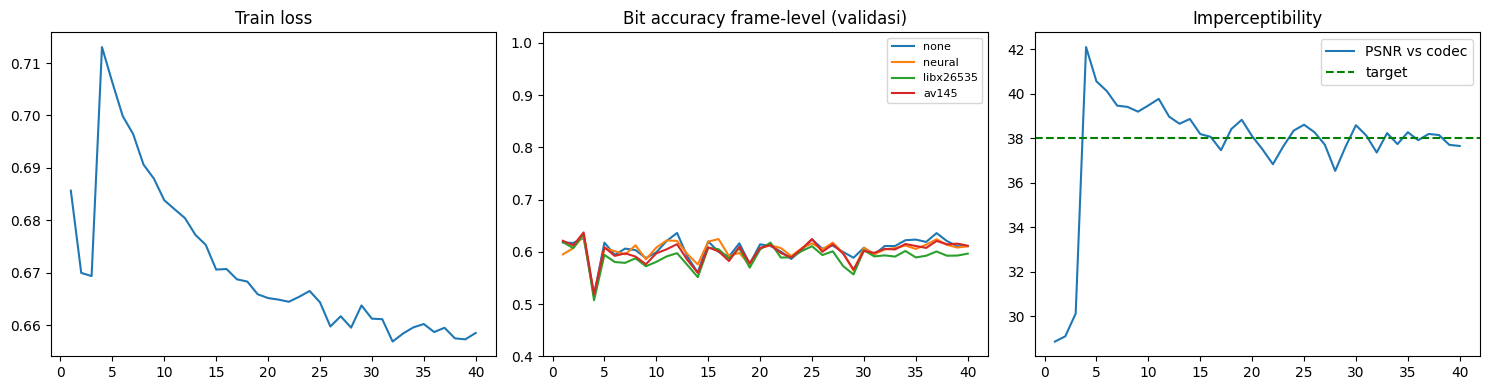

In [12]:
def psnr_t(a, b):
    return (10 * torch.log10(1.0 / F.mse_loss(a, b).clamp_min(1e-10))).item()


def _gauss_kernel(sigma, k=5):
    ax = torch.arange(k, dtype=torch.float32, device=device) - k // 2
    g = torch.exp(-ax ** 2 / (2 * sigma ** 2)); g = g / g.sum()
    return (g[:, None] * g[None, :]).expand(3, 1, k, k).contiguous()


def sample_clips(cache, n_clips=CLIPS_PER_BATCH, clip_len=CLIP_LEN):
    clips = []
    keys = list(cache.keys())
    for _ in range(n_clips):
        a = cache[random.choice(keys)]
        s = random.randint(0, max(len(a) - clip_len, 0))
        c = a[s:s + clip_len]
        if len(c) < clip_len:
            c = np.concatenate([c, np.repeat(c[-1:], clip_len - len(c), 0)])
        clips.append(c)
    return np.concatenate(clips)             # (n_clips*clip_len, H, W, 3)


def bpda_real_codec(x, n_clips, codec_name, crf):
    '''Forward: kompresi ffmpeg sungguhan per klip. Backward: identity (BPDA).'''
    frames = to_uint8(x.detach())
    out = []
    for c in np.split(frames, n_clips):
        out.append(ffmpeg_roundtrip(c, 25, codec_name, crf)[0])
    xc = to_tensor(np.concatenate(out)).to(x.device)
    return x + (xc - x).detach()


def attack_layer(x, n_clips, epoch):
    if epoch <= WARMUP_EPOCHS:
        return x, 'none'
    if random.random() < REAL_CODEC_PROB:
        options = [c for c in REAL_CODECS if not (c[0] == 'av1' and AV1_ENCODER is None)]
        name, (lo, hi) = random.choice(options)
        return bpda_real_codec(x, n_clips, name, random.randint(lo, hi)), name
    mode = random.choice(['identity', 'gauss', 'blur', 'rescale', 'color', 'neural', 'neural'])
    if mode == 'gauss':
        x = x + torch.randn_like(x) * random.uniform(0.005, 0.03)
    elif mode == 'blur':
        x = F.conv2d(F.pad(x, (2, 2, 2, 2), mode='replicate'), _gauss_kernel(random.uniform(0.5, 1.2)), groups=3)
    elif mode == 'rescale':
        s = random.uniform(0.5, 0.9); H, W = x.shape[-2:]
        x = F.interpolate(F.interpolate(x, scale_factor=s, mode='bilinear', align_corners=False),
                          size=(H, W), mode='bilinear', align_corners=False)
    elif mode == 'color':
        x = (x - 0.5) * random.uniform(0.8, 1.2) + 0.5 + random.uniform(-0.08, 0.08)
    elif mode == 'neural':
        x = codec_roundtrip(x, differentiable=True)
    return x.clamp(0, 1), mode


def embed_tensor(x, msg, alpha=1.0, differentiable=True):
    with torch.no_grad():
        y = codec.g_a(x)
    y_w, delta = embedder(y, msg, alpha)
    y_w_hat = ste_round(y_w) if differentiable else torch.round(y_w)
    return codec.g_s(y_w_hat).clamp(0, 1), y, y_w


@torch.no_grad()
def validate(n_frames=16):
    embedder.eval(); extractor.eval()
    res = {'psnr_codec': [], 'psnr_orig': [], 'ssim_codec': []}
    attacks = [('none', None), ('neural', None), ('libx265', 35)] + ([('av1', 45)] if AV1_ENCODER else [])
    acc = {f'{a}{"" if c is None else c}': [] for a, c in attacks}
    vacc = {k: [] for k in acc}
    rng = np.random.RandomState(0)
    for v, frames in val_cache.items():
        f = frames[:n_frames]
        x = to_tensor(f).to(device)
        msg = torch.from_numpy(rng.randint(0, 2, MSG_BITS).astype(np.float32)).to(device)
        msgs = msg.expand(len(f), -1)
        x_w, y, _ = embed_tensor(x, msgs, differentiable=False)
        x_c = codec.g_s(torch.round(y)).clamp(0, 1)
        x_w_u8 = to_uint8(x_w)
        x_w = to_tensor(x_w_u8).to(device)
        res['psnr_codec'].append(psnr_t(x_w, x_c)); res['psnr_orig'].append(psnr_t(x_w, x))
        res['ssim_codec'].append(ssim_torch(x_w, x_c, data_range=1.0).item())
        for a, c in attacks:
            k = f'{a}{"" if c is None else c}'
            if a == 'none':
                xa = x_w
            elif a == 'neural':
                xa = codec_roundtrip(x_w)
            else:
                xa = to_tensor(ffmpeg_roundtrip(x_w_u8, 25, a, c)[0]).to(device)
            logits = extractor(xa)
            acc[k].append(((logits > 0).float() == msgs).float().mean().item())
            vacc[k].append(((logits.mean(0) > 0).float() == msg).float().mean().item())
    out = {k: float(np.mean(v)) for k, v in res.items()}
    out.update({f'acc_{k}': float(np.mean(v)) for k, v in acc.items()})
    out.update({f'vacc_{k}': float(np.mean(v)) for k, v in vacc.items()})
    out['score'] = float(np.mean([np.mean(v) for v in acc.values()]))
    embedder.train(); extractor.train()
    return out


# ------------------------------------------------------------
# UJI KEWARASAN (sanity check): tanpa serangan & tanpa loss citra, pesan acak HARUS bisa
# dipelajari. Jika akurasi tidak naik, ada masalah pada setup (bukan soal robustness).
# ------------------------------------------------------------
def sanity_check(steps=SANITY_STEPS):
    opt_s = torch.optim.Adam(list(embedder.parameters()) + list(extractor.parameters()), lr=LR)
    embedder.train(); extractor.train()
    accs = []
    for i in range(steps):
        x = to_tensor(sample_clips(train_cache)).to(device)
        m = torch.randint(0, 2, (x.size(0), MSG_BITS), device=device).float()
        x_w, _, _ = embed_tensor(x, m)
        logits = extractor(x_w)
        loss = bce(logits, m)
        opt_s.zero_grad(); loss.backward(); opt_s.step()
        accs.append(((logits > 0).float() == m).float().mean().item())
        if (i + 1) % max(1, steps // 6) == 0:
            print(f'  sanity step {i+1}/{steps}: bce={loss.item():.3f} bit_acc={np.mean(accs[-20:]):.3f}')
    final = float(np.mean(accs[-20:]))
    if final < 0.85:
        print(f'[PERINGATAN] bit_acc sanity hanya {final:.3f}. Periksa: bobot codec pretrained termuat? '
              f'FRAME_SIZE terlalu kecil? Coba naikkan DELTA_MAX (mis. 3.0) atau SANITY_STEPS.')
    else:
        print(f'[OK] Pesan dapat dipelajari (bit_acc {final:.3f}). Lanjut ke training penuh.')
    return final


bce = nn.BCEWithLogitsLoss()
if not os.path.exists(os.path.join(OUTPUT_DIR, 'models', 'wm_checkpoint.pth')):
    SANITY_ACC = sanity_check()

optimizer = torch.optim.Adam(list(embedder.parameters()) + list(extractor.parameters()), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=LR * 0.05)
CKPT_PATH = os.path.join(OUTPUT_DIR, 'models', 'wm_checkpoint.pth')
BEST_PATH = os.path.join(OUTPUT_DIR, 'models', 'wm_best.pth')

history, start_epoch, lam_img, best_score = [], 1, LAMBDA_IMG_INIT, -1.0
if os.path.exists(CKPT_PATH):
    ck = torch.load(CKPT_PATH, map_location=device, weights_only=False)
    embedder.load_state_dict(ck['embedder']); extractor.load_state_dict(ck['extractor'])
    optimizer.load_state_dict(ck['optimizer']); scheduler.load_state_dict(ck['scheduler'])
    history, lam_img, best_score = ck['history'], ck['lam_img'], ck['best_score']
    start_epoch = ck['epoch'] + 1
    print(f'[RESUME] lanjut dari epoch {start_epoch}')

embedder.train(); extractor.train()
for epoch in range(start_epoch, EPOCHS + 1):
    t0 = time.time()
    lam_eff = lam_img * (0.0 if epoch <= WARMUP_EPOCHS else 1.0)
    stats = {'loss': 0, 'msg': 0, 'mse': 0, 'rate': 0, 'acc': 0}
    mode_count = {}
    for step in range(STEPS_PER_EPOCH):
        x = to_tensor(sample_clips(train_cache)).to(device)
        if random.random() < 0.5:
            x = torch.flip(x, dims=[3])
        msgs = torch.randint(0, 2, (CLIPS_PER_BATCH, MSG_BITS), device=device).float()
        msg_f = msgs.repeat_interleave(CLIP_LEN, 0)

        x_w, y, y_w = embed_tensor(x, msg_f)
        with torch.no_grad():
            x_c = codec.g_s(torch.round(y)).clamp(0, 1)
            rate0 = latent_rate_bits(y)
        x_att, mode = attack_layer(x_w, CLIPS_PER_BATCH, epoch)
        mode_count[mode] = mode_count.get(mode, 0) + 1
        logits = extractor(x_att)

        loss_msg = bce(logits, msg_f)
        loss_mse = F.mse_loss(x_w, x_c)
        loss_ssim = 1 - ssim_torch(x_w, x_c, data_range=1.0)
        loss_rate = F.relu(latent_rate_bits(y_w) - rate0).mean() / (x.shape[2] * x.shape[3])
        loss = loss_msg + lam_eff * (MSE_SCALE * loss_mse + loss_ssim) + LAMBDA_RATE * loss_rate

        optimizer.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(list(embedder.parameters()) + list(extractor.parameters()), 5.0)
        optimizer.step()

        stats['loss'] += loss.item(); stats['msg'] += loss_msg.item(); stats['mse'] += loss_mse.item()
        stats['rate'] += loss_rate.item()
        stats['acc'] += ((logits > 0).float() == msg_f).float().mean().item()
    scheduler.step()
    stats = {k: v / STEPS_PER_EPOCH for k, v in stats.items()}

    val = validate()
    if epoch > WARMUP_EPOCHS:   # anggaran imperceptibility adaptif
        lam_img = float(np.clip(lam_img * (1.25 if val['psnr_codec'] < TARGET_PSNR else 0.85), 0.05, 100.0))
    rec = {'epoch': epoch, 'lam_img': lam_eff, **{f'train_{k}': v for k, v in stats.items()}, **val}
    history.append(rec)

    eligible = val['psnr_codec'] >= TARGET_PSNR - 1.0 or epoch <= WARMUP_EPOCHS
    if eligible and val['score'] > best_score and epoch > WARMUP_EPOCHS:
        best_score = val['score']
        torch.save({'embedder': embedder.state_dict(), 'extractor': extractor.state_dict(), 'epoch': epoch,
                    'val': val}, BEST_PATH)
    torch.save({'embedder': embedder.state_dict(), 'extractor': extractor.state_dict(),
                'optimizer': optimizer.state_dict(), 'scheduler': scheduler.state_dict(),
                'history': history, 'lam_img': lam_img, 'best_score': best_score, 'epoch': epoch}, CKPT_PATH)

    acc_txt = ' '.join(f'{k[4:]}={v:.3f}' for k, v in val.items() if k.startswith('acc_'))
    print(f'Ep {epoch:03d} | {time.time()-t0:5.0f}s | loss={stats["loss"]:.3f} acc_train={stats["acc"]:.3f} | '
          f'VAL PSNR(vs codec)={val["psnr_codec"]:.2f} SSIM={val["ssim_codec"]:.4f} | {acc_txt} | λimg={lam_eff:.2f}')

if not os.path.exists(BEST_PATH):   # misal QUICK_TEST: simpan model terakhir sebagai "best"
    torch.save({'embedder': embedder.state_dict(), 'extractor': extractor.state_dict(), 'epoch': EPOCHS,
                'val': history[-1] if history else {}}, BEST_PATH)

hist_df = pd.DataFrame(history)
hist_df.to_csv(os.path.join(OUTPUT_DIR, 'training_history.csv'), index=False)
if len(hist_df):
    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    ax[0].plot(hist_df['epoch'], hist_df['train_loss']); ax[0].set_title('Train loss')
    for c in [c for c in hist_df.columns if c.startswith('acc_')]:
        ax[1].plot(hist_df['epoch'], hist_df[c], label=c[4:])
    ax[1].set_title('Bit accuracy frame-level (validasi)'); ax[1].legend(fontsize=8); ax[1].set_ylim(0.4, 1.02)
    ax[2].plot(hist_df['epoch'], hist_df['psnr_codec'], label='PSNR vs codec')
    ax[2].axhline(TARGET_PSNR, ls='--', c='g', label='target'); ax[2].legend(); ax[2].set_title('Imperceptibility')
    plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, 'training_curve.png'), dpi=130); plt.show()

## 7. Output 1 — Algoritma Watermarking (fungsi siap pakai)

| Fungsi | Peran |
|---|---|
| `embed_video(frames, msg, alpha)` | Input Video → **g_a** → **embedding latent** → entropy coding nyata → **g_s** → Video Output |
| `extract_logits(frames)` | video diterima → g_a → extractor → logit per frame |
| `phash_frames(frames)` | sidik jari konten per frame (dipakai validasi integritas) |
| registry (`registry.json`) | catatan setiap video yang di-watermark: ID, pemilik, payload, SHA-256, pHash per frame, metrik |

In [13]:
_best = torch.load(BEST_PATH, map_location=device, weights_only=False)
embedder.load_state_dict(_best['embedder']); extractor.load_state_dict(_best['extractor'])
embedder.eval(); extractor.eval()
print(f"Model terbaik dimuat (epoch {_best['epoch']}).")

CHUNK = 16


@torch.no_grad()
def embed_video(frames_u8, msg_bits, alpha=ALPHA_INIT, with_reference=False):
    '''Output 1: embedding watermark di latent neural codec dengan bitstream NYATA.
    Return: frame watermarked (uint8), [frame codec tanpa watermark], rata-rata byte/frame (wm, ref).'''
    msg = torch.from_numpy(np.asarray(msg_bits, np.float32)).to(device)
    out_wm, out_ref, bytes_wm, bytes_ref = [], [], [], []
    for i in range(0, len(frames_u8), CHUNK):
        x = to_tensor(frames_u8[i:i + CHUNK]).to(device)
        y = codec.g_a(x)                                           # Neural Codec Encoder
        y_w, _ = embedder(y, msg.expand(len(x), -1), alpha)        # Watermark Embedding (latent)
        y_w_hat, nb = codec_code_latent(y_w)                       # kuantisasi + entropy coding
        out_wm.append(to_uint8(codec.g_s(y_w_hat)))                # Neural Codec Decoder
        bytes_wm += nb
        if with_reference:
            y_hat, nb0 = codec_code_latent(y)
            out_ref.append(to_uint8(codec.g_s(y_hat))); bytes_ref += nb0
    wm = np.concatenate(out_wm)
    ref = np.concatenate(out_ref) if with_reference else None
    return wm, ref, float(np.mean(bytes_wm)), (float(np.mean(bytes_ref)) if with_reference else None)


@torch.no_grad()
def extract_logits(frames_u8):
    outs = []
    for i in range(0, len(frames_u8), CHUNK):
        outs.append(extractor(to_tensor(frames_u8[i:i + CHUNK]).to(device)).cpu().numpy())
    return np.concatenate(outs)


def rescan_frames(frames_u8):
    return decode_message(extract_logits(frames_u8).mean(0))


def phash_frame(f):
    g = cv2.resize(cv2.cvtColor(f, cv2.COLOR_RGB2GRAY), (32, 32), interpolation=cv2.INTER_AREA).astype(np.float32)
    d = cv2.dct(g)[:8, :8].flatten()
    bits = (d > np.median(d[1:])).astype(np.uint8)
    return int(''.join(map(str, bits)), 2)


def phash_frames(frames):
    return [phash_frame(f) for f in frames]


def hamming64(a, b):
    return bin(int(a) ^ int(b)).count('1')


def apply_attack(frames_u8, fps, attack):
    '''Serangan untuk evaluasi. Return (frame hasil, bpp file atau None).'''
    name, p = attack
    T, H, W, _ = frames_u8.shape
    if name == 'none':
        return frames_u8, None
    if name == 'neural':
        out = [to_uint8(codec_roundtrip(to_tensor(frames_u8[i:i + CHUNK]).to(device)))
               for i in range(0, T, CHUNK)]
        return np.concatenate(out), None
    if name == 'rescale':
        small = [cv2.resize(f, (int(W * p) // 2 * 2, int(H * p) // 2 * 2), interpolation=cv2.INTER_AREA) for f in frames_u8]
        return np.stack([cv2.resize(f, (W, H), interpolation=cv2.INTER_LINEAR) for f in small]), None
    out, size = ffmpeg_roundtrip(frames_u8, fps, name, p)
    return out, size * 8 / (T * H * W)


def load_registry():
    if os.path.exists(REGISTRY_PATH):
        with open(REGISTRY_PATH) as f:
            return json.load(f)
    return {}


def save_registry(reg):
    with open(REGISTRY_PATH, 'w') as f:
        json.dump(reg, f, indent=1)


print('Fungsi Output 1 siap.')

Model terbaik dimuat (epoch 37).
Fungsi Output 1 siap.


## 8. Loop Flowchart Pembimbing pada Data Uji

| Fungsi | Kotak flowchart |
|---|---|
| `insert_watermark(...)` | Insert Watermark (embedding latent neural codec) |
| `compress_video(...)` | Compress Video — **HEVC CRF 35** (`LOOP_ATTACK`), sesuai latar belakang riset |
| `rescan_watermark(...)` | Rescan Watermark |
| `is_legible(...)` | CRC valid **dan** ID sama dengan yang disisipkan |
| `run_watermark_pipeline(...)` | loop retry (α dinaikkan, maks `MAX_RETRY`) + pendaftaran ke registry |

Pada versi lama, kotak *Compress Video* memakai neural codec yang sama dengan yang dilatihkan, sehingga pengujian terlalu mudah. Karena neural codec sekarang menjadi **domain penyisipan**, kotak kompresi diisi codec konvensional berkompresi tinggi yang memang menjadi masalah pada latar belakang riset.

In [14]:
registry = load_registry()


def insert_watermark(video_name, frames, fps, wm_id, alpha):
    '''[Insert Watermark]'''
    msg = build_message(wm_id)
    wm, ref, b_wm, b_ref = embed_video(frames, msg, alpha, with_reference=True)
    path = os.path.join(OUTPUT_DIR, 'watermarked', os.path.splitext(video_name)[0] + '_wm.mkv')
    write_video(wm, path, fps, codec='ffv1')
    return path, wm, ref, b_wm, b_ref


def compress_video(path, video_name, fps, attack=LOOP_ATTACK):
    '''[Compress Video] HEVC CRF tinggi (default).'''
    frames, _, _ = read_video(path, max_frames=None)
    name, crf = attack
    out = os.path.join(OUTPUT_DIR, 'compressed', f'{os.path.splitext(video_name)[0]}_wm_{name}_crf{crf}{codec_ext(name)}')
    write_video(frames, out, fps, codec=name, crf=crf)
    return out


def rescan_watermark(path):
    '''[Rescan Watermark]'''
    frames, _, _ = read_video(path, max_frames=None)
    return rescan_frames(frames)


def is_legible(dec, wm_id):
    '''[is legible Watermark?]'''
    return dec['crc_ok'] and dec['id'] == wm_id


def run_watermark_pipeline(video_name, max_retry=MAX_RETRY, verbose=True):
    frames, fps, orig_size = read_video(os.path.join(DATASET_DIR, video_name))
    created = datetime.datetime.now().isoformat(timespec='seconds')
    wm_id = make_watermark_id(OWNER_TEXT, video_name, created)
    for attempt in range(1, max_retry + 1):
        alpha = ALPHA_INIT * (1 + RETRY_ALPHA_STEP * (attempt - 1))
        wm_path, wm, ref, b_wm, b_ref = insert_watermark(video_name, frames, fps, wm_id, alpha)
        comp_path = compress_video(wm_path, video_name, fps)
        dec = rescan_watermark(comp_path)
        ok = is_legible(dec, wm_id)
        if verbose:
            print(f'[{video_name}] percobaan {attempt}/{max_retry} α={alpha:.2f} -> ID terbaca {dec["id_hex"]} '
                  f'CRC={dec["crc_ok"]} conf={dec["confidence"]:.3f} -> {"LEGIBLE" if ok else "tidak legible"}')
        if ok:
            break
    hw = FRAME_SIZE[0] * FRAME_SIZE[1]
    record = {
        'wm_id': f'{wm_id:08x}', 'owner': OWNER_TEXT, 'video_name': video_name, 'created_at': created,
        'payload_bits': ''.join(map(str, build_message(wm_id).astype(int))), 'alpha': alpha,
        'attempts': attempt, 'legible': bool(ok), 'n_frames': int(len(wm)), 'fps': fps,
        'frame_size': list(FRAME_SIZE), 'orig_size': list(orig_size),
        'sha256_known': [sha256_file(wm_path), sha256_file(comp_path)],
        'phash': [f'{h:016x}' for h in phash_frames(wm)],
        'bpp_wm': b_wm * 8 / hw, 'bpp_codec': b_ref * 8 / hw,
        'watermarked_path': wm_path, 'compressed_path': comp_path,
    }
    if ok:
        registry[record['wm_id']] = record
        save_registry(registry)
    return record, frames, wm, ref


pipeline_rows, eval_store = [], {}
for v in eval_videos:
    rec, frames, wm, ref = run_watermark_pipeline(v)
    eval_store[v] = {'orig': frames, 'wm': wm, 'ref': ref, 'record': rec}
    pipeline_rows.append({k: rec[k] for k in ['video_name', 'wm_id', 'legible', 'attempts', 'alpha', 'bpp_codec', 'bpp_wm']})
    if rec['legible']:
        print(f'    -> print(True, "{rec["payload_bits"]}")')

df_pipeline = pd.DataFrame(pipeline_rows)
df_pipeline.to_csv(os.path.join(OUTPUT_DIR, 'hasil_pipeline.csv'), index=False)
display(df_pipeline)
print(f'\nRingkasan: {df_pipeline["legible"].sum()}/{len(df_pipeline)} video legible setelah '
      f'{LOOP_ATTACK[0]} CRF {LOOP_ATTACK[1]} (maks {MAX_RETRY} percobaan). '
      f'Rata-rata percobaan: {df_pipeline["attempts"].mean():.2f}')

[v_Punch_g07_c01.avi] percobaan 1/5 α=1.00 -> ID terbaca f067ec44 CRC=False conf=0.194 -> tidak legible
[v_Punch_g07_c01.avi] percobaan 2/5 α=1.25 -> ID terbaca f077ee44 CRC=False conf=0.250 -> tidak legible
[v_Punch_g07_c01.avi] percobaan 3/5 α=1.50 -> ID terbaca f077ee44 CRC=False conf=0.277 -> tidak legible
[v_Punch_g07_c01.avi] percobaan 4/5 α=1.75 -> ID terbaca f077ee44 CRC=False conf=0.296 -> tidak legible
[v_Punch_g07_c01.avi] percobaan 5/5 α=2.00 -> ID terbaca f077ee44 CRC=False conf=0.310 -> tidak legible
[v_TennisSwing_g04_c05.avi] percobaan 1/5 α=1.00 -> ID terbaca f026e664 CRC=False conf=0.249 -> tidak legible
[v_TennisSwing_g04_c05.avi] percobaan 2/5 α=1.25 -> ID terbaca f066e664 CRC=False conf=0.252 -> tidak legible
[v_TennisSwing_g04_c05.avi] percobaan 3/5 α=1.50 -> ID terbaca f066e664 CRC=False conf=0.256 -> tidak legible
[v_TennisSwing_g04_c05.avi] percobaan 4/5 α=1.75 -> ID terbaca f066e664 CRC=False conf=0.261 -> tidak legible
[v_TennisSwing_g04_c05.avi] percobaan 5/

,video_name,wm_id,legible,attempts,alpha,bpp_codec,bpp_wm
0,v_Punch_g07_c01.avi,a327bf6f,False,5,2.0,0.273952,0.313014
1,v_TennisSwing_g04_c05.avi,3965edba,False,5,2.0,0.362819,0.393288
2,v_TennisSwing_g04_c07.avi,bdf615df,False,5,2.0,0.366608,0.384642
3,v_Punch_g03_c01.avi,cf0345b5,False,5,2.0,0.227663,0.250085
4,v_CricketShot_g06_c06.avi,f88dcfd3,False,5,2.0,0.316602,0.357813
5,v_Punch_g07_c05.avi,4f2b1bb3,False,5,2.0,0.366641,0.376048
6,v_TennisSwing_g02_c05.avi,3383f42d,False,5,2.0,0.324583,0.358184
7,v_PlayingCello_g06_c01.avi,c003884d,False,5,2.0,0.162064,0.216380
8,v_PlayingCello_g03_c03.avi,58e5873b,False,5,2.0,0.168255,0.237760
9,v_ShavingBeard_g02_c01.avi,ddad7ad3,False,5,2.0,0.168939,0.196621



Ringkasan: 0/30 video legible setelah libx265 CRF 35 (maks 5 percobaan). Rata-rata percobaan: 5.00


## 9. Evaluasi Lengkap (data uji, grup tidak pernah dilihat saat training)

1. **Imperceptibility** — PSNR & SSIM terhadap (a) video asli dan (b) output neural codec *tanpa* watermark. Nilai (b) mengukur distorsi yang murni disebabkan watermark; nilai (a) juga memuat distorsi codec itu sendiri. Kenaikan bitrate (bpp) akibat watermark ikut dilaporkan.
2. **Robustness** — BER tingkat video (soft voting antar frame) dan tingkat frame, serta *legible rate* (CRC valid + ID cocok) setelah: tanpa serangan, neural codec, H.264, HEVC, AV1 pada beberapa CRF, dan rescale 50%.
3. **False positive** — video asli tanpa watermark (juga setelah HEVC) diperiksa: berapa kali sistem keliru menyatakan ada watermark. Uji ini yang **tidak ada** di notebook lama, padahal paling penting untuk membuktikan decoder tidak sekadar menghafal.
4. **Baseline tradisional (DCT-QIM)** — watermark domain-DCT blok 8×8 pada kanal luma, payload sama, serangan sama. Kekuatannya **dikalibrasi otomatis** agar PSNR-nya setara dengan distorsi watermark usulan, sehingga perbandingan robustness adil (bukan baseline yang sengaja dibuat lemah). Ini mendukung klaim latar belakang bahwa watermark tradisional rusak oleh kompresi tinggi.

Kalibrasi baseline: target PSNR 32.56 dB -> QIM_STEP = 79.99


Evaluasi:   0%|          | 0/30 [00:00<?, ?it/s]

=== IMPERCEPTIBILITY (rata-rata) ===


,rata-rata
PSNR_wm_vs_asli,30.4746
SSIM_wm_vs_asli,0.8614
PSNR_wm_vs_codec,32.5647
SSIM_wm_vs_codec,0.9077
PSNR_codec_vs_asli,33.2732
SSIM_codec_vs_asli,0.9184
bpp_codec,0.2576
bpp_wm,0.2948
PSNR_baseline_vs_asli,39.5458
SSIM_baseline_vs_asli,0.9533



=== ROBUSTNESS (rata-rata per serangan) ===


,serangan,metode,BER_video,BER_frame,legible_rate,bpp_file
24,none,DCT-QIM (tradisional),0.0000,0.0000,1.0000,NaN
25,none,Latent Neural Codec (usulan),0.4104,0.4127,0.0000,NaN
22,neural,DCT-QIM (tradisional),0.4201,0.4245,0.0000,NaN
23,neural,Latent Neural Codec (usulan),0.4104,0.4099,0.0000,NaN
6,libx264_23,DCT-QIM (tradisional),0.0160,0.0356,0.8000,0.1209
7,libx264_23,Latent Neural Codec (usulan),0.4111,0.4125,0.0000,0.1385
8,libx264_30,DCT-QIM (tradisional),0.3243,0.3260,0.0000,0.0455
9,libx264_30,Latent Neural Codec (usulan),0.4104,0.4105,0.0000,0.0532
10,libx264_35,DCT-QIM (tradisional),0.4562,0.4558,0.0000,0.0268
11,libx264_35,Latent Neural Codec (usulan),0.4056,0.4067,0.0000,0.0291



=== FALSE POSITIVE (video tanpa watermark) ===


,crc_ok,id_terdaftar,deteksi_statistik
kondisi,,,
asli,0.0,0.0,0.0
asli + HEVC CRF35,0.0,0.0,0.0


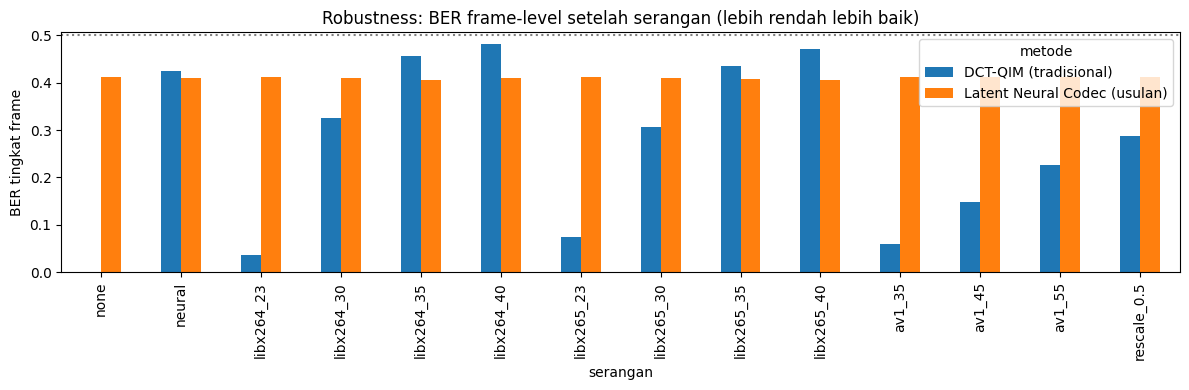

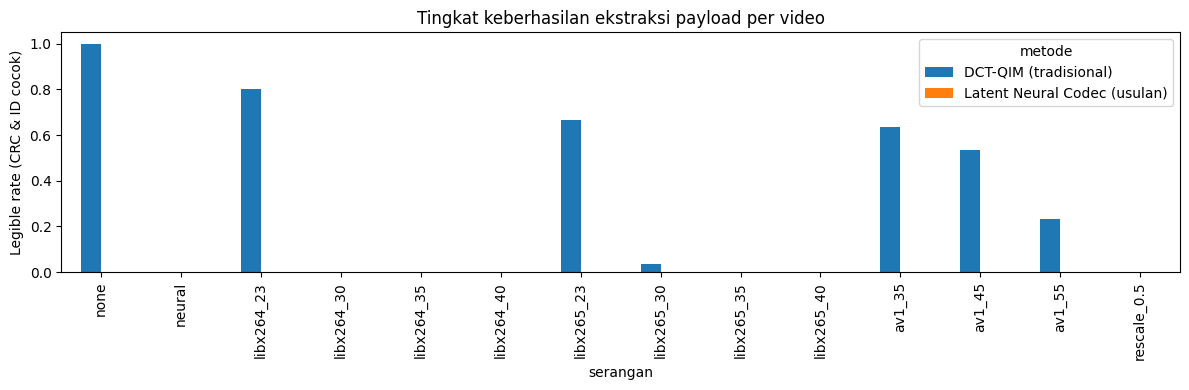

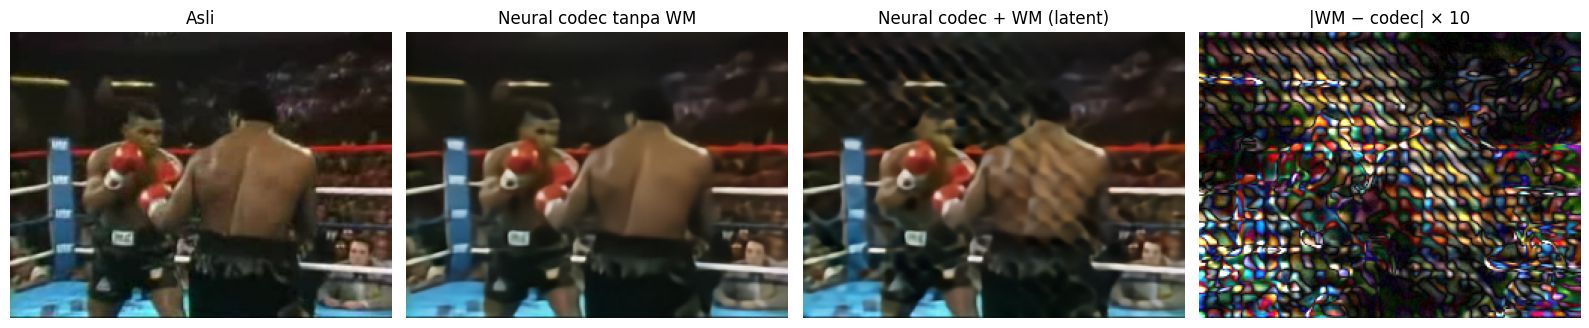

In [15]:
from skimage.metrics import peak_signal_noise_ratio as sk_psnr, structural_similarity as sk_ssim

# ---------------- Baseline tradisional: DCT-QIM (luma, blok 8x8) ----------------
_D = cv2.dct(np.eye(8, dtype=np.float32))          # matriks DCT ortonormal 8x8
QIM_COEF = (1, 2)


def _blocks(Y):
    H8, W8 = Y.shape[0] // 8 * 8, Y.shape[1] // 8 * 8
    return Y[:H8, :W8].reshape(H8 // 8, 8, W8 // 8, 8).transpose(0, 2, 1, 3), (H8, W8)


def qim_embed(frames_u8, msg_bits, step=QIM_STEP):
    bits = np.asarray(msg_bits).astype(int)
    out = []
    for f in frames_u8:
        ycc = cv2.cvtColor(f, cv2.COLOR_RGB2YCrCb).astype(np.float32)
        B, (H8, W8) = _blocks(ycc[..., 0])
        C = _D @ B @ _D.T
        k = np.arange(B.shape[0] * B.shape[1]).reshape(B.shape[:2]) % len(bits)
        dither = (bits[k] * 2 - 1) * step / 4
        c = C[..., QIM_COEF[0], QIM_COEF[1]]
        C[..., QIM_COEF[0], QIM_COEF[1]] = step * np.round((c - dither) / step) + dither
        B2 = _D.T @ C @ _D
        ycc[:H8, :W8, 0] = B2.transpose(0, 2, 1, 3).reshape(H8, W8)
        out.append(cv2.cvtColor(np.clip(np.round(ycc), 0, 255).astype(np.uint8), cv2.COLOR_YCrCb2RGB))
    return np.stack(out)


def qim_soft(frames_u8, n_bits=MSG_BITS, step=QIM_STEP):
    '''Return soft value per frame per bit (positif -> bit 1), bentuk (T, n_bits).'''
    res = []
    for f in frames_u8:
        Y = cv2.cvtColor(f, cv2.COLOR_RGB2YCrCb).astype(np.float32)[..., 0]
        B, _ = _blocks(Y)
        c = (_D @ B @ _D.T)[..., QIM_COEF[0], QIM_COEF[1]].ravel()
        d = {}
        for b in (0, 1):
            dith = (b * 2 - 1) * step / 4
            d[b] = np.abs(c - (step * np.round((c - dith) / step) + dith))
        s = (d[0] - d[1]) / (step / 4)
        k = np.arange(len(c)) % n_bits
        res.append(np.bincount(k, weights=s, minlength=n_bits) / np.maximum(np.bincount(k, minlength=n_bits), 1))
    return np.stack(res)


def frame_metrics(a, b, every=4):
    idx = range(0, len(a), every)
    p = np.mean([sk_psnr(a[i], b[i], data_range=255) for i in idx])
    s = np.mean([sk_ssim(a[i], b[i], channel_axis=2, data_range=255) for i in idx])
    return float(p), float(s)


def attack_label(a):
    return a[0] if a[1] is None else f'{a[0]}_{a[1]}'


def calibrate_qim_step(frames_list, msg, target_psnr, lo=2.0, hi=80.0, iters=12):
    """Cari QIM_STEP agar PSNR baseline ~ PSNR distorsi watermark usulan (perbandingan adil)."""
    for _ in range(iters):
        mid = (lo + hi) / 2
        p = np.mean([frame_metrics(qim_embed(f, msg, mid), f, every=8)[0] for f in frames_list])
        lo, hi = (mid, hi) if p > target_psnr else (lo, mid)
    return (lo + hi) / 2


imp_rows, rob_rows, fp_rows = [], [], []
# 1) Imperceptibility metode usulan
for v, st in eval_store.items():
    rec, orig, wm, ref = st['record'], st['orig'], st['wm'], st['ref']
    p_wo, s_wo = frame_metrics(wm, orig); p_wr, s_wr = frame_metrics(wm, ref); p_ro, s_ro = frame_metrics(ref, orig)
    imp_rows.append({'video': v, 'PSNR_wm_vs_asli': p_wo, 'SSIM_wm_vs_asli': s_wo,
                     'PSNR_wm_vs_codec': p_wr, 'SSIM_wm_vs_codec': s_wr,
                     'PSNR_codec_vs_asli': p_ro, 'SSIM_codec_vs_asli': s_ro,
                     'bpp_codec': rec['bpp_codec'], 'bpp_wm': rec['bpp_wm']})

# 2) Kalibrasi baseline: distorsi DCT-QIM disamakan dengan distorsi watermark usulan
_target = float(np.mean([r['PSNR_wm_vs_codec'] for r in imp_rows]))
_cal_frames = [st['orig'][:24] for st in list(eval_store.values())[:3]]
QIM_STEP_CAL = calibrate_qim_step(_cal_frames, build_message(1).astype(int), _target)
print(f'Kalibrasi baseline: target PSNR {_target:.2f} dB -> QIM_STEP = {QIM_STEP_CAL:.2f}')

# 3) Robustness + false positive
for (v, st), imp in zip(tqdm(list(eval_store.items()), desc='Evaluasi'), imp_rows):
    rec, orig, wm = st['record'], st['orig'], st['wm']
    fps, wm_id = rec['fps'], int(rec['wm_id'], 16)
    msg = build_message(wm_id).astype(int)
    bl = qim_embed(orig, msg, QIM_STEP_CAL)
    imp['PSNR_baseline_vs_asli'], imp['SSIM_baseline_vs_asli'] = frame_metrics(bl, orig)

    for atk in EVAL_ATTACKS:
        if atk[0] == 'av1' and AV1_ENCODER is None:
            continue
        for method, src in [('Latent Neural Codec (usulan)', wm), ('DCT-QIM (tradisional)', bl)]:
            att, bpp = apply_attack(src, fps, atk)
            soft = extract_logits(att) if method.startswith('Latent') else qim_soft(att, step=QIM_STEP_CAL)
            dec = decode_message(soft.mean(0))
            rob_rows.append({'video': v, 'metode': method, 'serangan': attack_label(atk), 'bpp_file': bpp,
                             'BER_video': bit_error_rate((soft.mean(0) > 0).astype(int), msg),
                             'BER_frame': float(np.mean((soft > 0).astype(int) != msg[None])),
                             'legible': bool(dec['crc_ok'] and dec['id'] == wm_id)})

    # False positive: video ASLI tanpa watermark
    for kondisi, frames_neg in [('asli', orig), ('asli + HEVC CRF35', apply_attack(orig, fps, ('libx265', 35))[0])]:
        dec = decode_message(extract_logits(frames_neg).mean(0))
        best_p = 1.0
        for r in registry.values():
            ref_bits = np.array(list(r['payload_bits']), dtype=int)
            best_p = min(best_p, match_pvalue(int((dec['bits'] == ref_bits[:PAYLOAD_BITS]).sum()), PAYLOAD_BITS))
        fp_rows.append({'video': v, 'kondisi': kondisi, 'crc_ok': dec['crc_ok'],
                        'id_terdaftar': dec['crc_ok'] and dec['id_hex'] in registry,
                        'p_value_terbaik': best_p, 'deteksi_statistik': best_p < DETECT_PVALUE})

df_imp, df_rob, df_fp = pd.DataFrame(imp_rows), pd.DataFrame(rob_rows), pd.DataFrame(fp_rows)
for name, df in [('eval_imperceptibility', df_imp), ('eval_robustness', df_rob), ('eval_false_positive', df_fp)]:
    df.to_csv(os.path.join(OUTPUT_DIR, f'{name}.csv'), index=False)

print('=== IMPERCEPTIBILITY (rata-rata) ===')
display(df_imp.drop(columns='video').mean().round(4).to_frame('rata-rata'))

order = [attack_label(a) for a in EVAL_ATTACKS if not (a[0] == 'av1' and AV1_ENCODER is None)]
summary = (df_rob.groupby(['serangan', 'metode'])
           .agg(BER_video=('BER_video', 'mean'), BER_frame=('BER_frame', 'mean'),
                legible_rate=('legible', 'mean'), bpp_file=('bpp_file', 'mean'))
           .reset_index())
summary['serangan'] = pd.Categorical(summary['serangan'], order, ordered=True)
summary = summary.sort_values(['serangan', 'metode'])
summary.to_csv(os.path.join(OUTPUT_DIR, 'eval_robustness_ringkas.csv'), index=False)
print('\n=== ROBUSTNESS (rata-rata per serangan) ===')
display(summary.round(4))

print('\n=== FALSE POSITIVE (video tanpa watermark) ===')
display(df_fp.groupby('kondisi')[['crc_ok', 'id_terdaftar', 'deteksi_statistik']].mean())

# ---- Grafik ----
piv = summary.pivot(index='serangan', columns='metode', values='BER_frame').loc[order]
piv.plot(kind='bar', figsize=(12, 4)); plt.ylabel('BER tingkat frame'); plt.axhline(0.5, ls=':', c='gray')
plt.title('Robustness: BER frame-level setelah serangan (lebih rendah lebih baik)'); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eval_ber_frame.png'), dpi=130); plt.show()

piv2 = summary.pivot(index='serangan', columns='metode', values='legible_rate').loc[order]
piv2.plot(kind='bar', figsize=(12, 4)); plt.ylabel('Legible rate (CRC & ID cocok)'); plt.ylim(0, 1.05)
plt.title('Tingkat keberhasilan ekstraksi payload per video'); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eval_legible_rate.png'), dpi=130); plt.show()

# ---- Contoh visual ----
_v0 = next(iter(eval_store)); _s = eval_store[_v0]; _i = len(_s['wm']) // 2
diff = np.clip(np.abs(_s['wm'][_i].astype(int) - _s['ref'][_i].astype(int)) * 10, 0, 255).astype(np.uint8)
fig, ax = plt.subplots(1, 4, figsize=(16, 3.6))
for a, img, t in zip(ax, [_s['orig'][_i], _s['ref'][_i], _s['wm'][_i], diff],
                     ['Asli', 'Neural codec tanpa WM', 'Neural codec + WM (latent)', '|WM − codec| × 10']):
    a.imshow(img); a.set_title(t); a.axis('off')
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, 'contoh_visual.png'), dpi=130); plt.show()

## 10. Output 2 — Sistem Verifikasi Otomatis & Validasi Integritas (Novelty 3)

`verify_video(path)` menjalankan alur **Upload → Ekstraksi → Validasi integritas → Laporan otomatis**:

| Tahap | Pemeriksaan | Dasar keputusan |
|---|---|---|
| Ekstraksi | payload dari seluruh frame (soft voting) | CRC-16 valid |
| Kepemilikan | ID dicari di registry; bila CRC gagal, dicari payload terdekat | *p-value* binomial < `DETECT_PVALUE` |
| Integritas file | SHA-256 dibandingkan dengan file yang terdaftar | identik bit-per-bit atau tidak |
| Integritas temporal | watermark dicek per segmen `SEGMENT_LEN` frame | akurasi bit segmen ≥ `SEG_BITACC_THRESH` |
| Integritas konten | pHash per frame dibandingkan dengan registry, setelah penyelarasan offset (tahan pemotongan awal) | jarak Hamming ≤ `PHASH_THRESH` |
| Kelengkapan | jumlah frame dibanding catatan | terpotong / ditambah |

Watermark bersifat **robust** (bertahan terhadap kompresi) sehingga membuktikan asal-usul, sedangkan pHash + pemeriksaan per segmen berfungsi sebagai lapisan **integritas** yang menunjukkan bagian mana yang diubah. Hasilnya disimpan sebagai JSON dan HTML di `OUTPUT_DIR/reports`.

Kemungkinan vonis: `AUTENTIK – IDENTIK`, `AUTENTIK – TERKOMPRESI ULANG, KONTEN UTUH`, `AUTENTIK – TERPOTONG`, `TERINDIKASI DIMANIPULASI`, `WATERMARK LEMAH / TIDAK PASTI`, `TIDAK ADA WATERMARK TERDAFTAR`.

In [16]:
def align_offset(ref_h, q_h):
    '''Cari offset terbaik: frame q[i] dipasangkan dengan ref[i + off].'''
    n_r, n_q = len(ref_h), len(q_h)
    min_overlap = max(3, min(n_r, n_q) // 3)
    best_off, best_d = 0, float('inf')
    for off in range(-(n_q - 1), n_r):
        i0, i1 = max(0, -off), min(n_q, n_r - off)
        if i1 - i0 < min_overlap:
            continue
        idx = range(i0, i1, max(1, (i1 - i0) // 40))
        d = np.mean([hamming64(q_h[i], ref_h[i + off]) for i in idx])
        if d < best_d:
            best_off, best_d = off, d
    return best_off, best_d


def _verdict_color(v):
    return '#1e8e3e' if v.startswith('AUTENTIK') else ('#d93025' if 'MANIPULASI' in v else '#e37400')


def _report_plot_b64(frame_acc, dists, segments, fps):
    fig, ax = plt.subplots(2, 1, figsize=(10, 4.2), sharex=True)
    t = np.arange(len(frame_acc)) / fps
    ax[0].plot(t, frame_acc, lw=1); ax[0].axhline(SEG_BITACC_THRESH, ls='--', c='g')
    ax[0].set_ylabel('akurasi bit\nper frame'); ax[0].set_ylim(0.3, 1.02)
    d = np.array([np.nan if x is None else x for x in dists], dtype=float)
    ax[1].plot(t, d, lw=1, c='tab:orange'); ax[1].axhline(PHASH_THRESH, ls='--', c='r')
    ax[1].set_ylabel('jarak pHash'); ax[1].set_xlabel('detik')
    for s in segments:
        if not s['ok']:
            for a in ax:
                a.axvspan(s['start_s'], s['end_s'], color='red', alpha=0.15)
    plt.tight_layout()
    buf = io.BytesIO(); fig.savefig(buf, format='png', dpi=100); plt.close(fig)
    return base64.b64encode(buf.getvalue()).decode()


def _to_builtin(o):
    if isinstance(o, dict):
        return {k: _to_builtin(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [_to_builtin(v) for v in o]
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.floating,)):
        return float(o)
    if isinstance(o, (np.bool_,)):
        return bool(o)
    return o


def render_html(rep, plot_b64=None):
    c = _verdict_color(rep['verdict'])
    rows = ''.join(f'<tr><th>{k}</th><td>{v}</td></tr>' for k, v in [
        ('File', rep['file']), ('Waktu verifikasi', rep['verified_at']),
        ('Resolusi / fps / codec', f"{rep['input']['width']}×{rep['input']['height']} / {rep['input']['fps']:.2f} / {rep['input']['codec']}"),
        ('Frame dianalisis', rep['input']['frames_analyzed']),
        ('ID terbaca', rep['extraction']['id_hex']), ('CRC valid', rep['extraction']['crc_ok']),
        ('Confidence', f"{rep['extraction']['confidence']:.3f}"),
        ('Metode identifikasi', rep['ownership'].get('method')), ('Pemilik', rep['ownership'].get('owner')),
        ('Video terdaftar', rep['ownership'].get('video_name')), ('Didaftarkan', rep['ownership'].get('created_at')),
        ('Bit cocok / p-value', f"{rep['ownership'].get('n_match')}/{PAYLOAD_BITS} / {rep['ownership'].get('p_value')}"),
        ('SHA-256 identik', rep['integrity'].get('sha256_match')),
        ('Frame tercatat / cocok', f"{rep['integrity'].get('frames_registered')} / {rep['integrity'].get('frames_matched')}"),
        ('Offset penyelarasan', rep['integrity'].get('offset')),
        ('Waktu proses', f"{rep['elapsed_s']:.1f} s")])
    seg_rows = ''.join(
        f"<tr style='background:{'#fff' if s['ok'] else '#fde7e7'}'><td>{s['index']}</td>"
        f"<td>{s['start_s']:.2f}–{s['end_s']:.2f}</td><td>{s['wm_bit_acc']:.3f}</td>"
        f"<td>{s['phash_median'] if s['phash_median'] is not None else '-'}</td>"
        f"<td>{'OK' if s['ok'] else ', '.join(s['issues'])}</td></tr>"
        for s in rep['integrity'].get('segments', []))
    img = f"<img style='max-width:100%' src='data:image/png;base64,{plot_b64}'/>" if plot_b64 else ''
    notes = ''.join(f'<li>{n}</li>' for n in rep['notes'])
    return f"""<html><head><meta charset='utf-8'><title>Laporan Verifikasi</title>
<style>body{{font-family:Arial,sans-serif;max-width:900px;margin:24px auto;color:#222}}
table{{border-collapse:collapse;width:100%;margin:10px 0}}th,td{{border:1px solid #ddd;padding:6px;text-align:left;font-size:13px}}
th{{background:#f5f5f5;width:35%}}.v{{padding:14px;border-radius:8px;color:#fff;font-size:20px;background:{c}}}</style></head>
<body><h2>Laporan Verifikasi Watermark &amp; Integritas Video</h2><div class='v'>{rep['verdict']}</div>
<ul>{notes}</ul><table>{rows}</table>{img}
<h3>Analisis per segmen</h3><table><tr><th>#</th><th>Waktu (s)</th><th>Akurasi bit WM</th><th>Median pHash</th><th>Status</th></tr>{seg_rows}</table>
</body></html>"""


def verify_video(path, reg=None, save=True):
    '''Output 2: Upload -> ekstraksi -> validasi integritas -> laporan otomatis.'''
    t0 = time.time()
    reg = load_registry() if reg is None else reg
    info = probe_video(path)
    frames, fps, _ = read_video(path, max_frames=MAX_VERIFY_FRAMES)
    logits = extract_logits(frames)
    dec = decode_message(logits.mean(0))
    rep = {'file': os.path.basename(path), 'verified_at': datetime.datetime.now().isoformat(timespec='seconds'),
           'input': {**info, 'frames_analyzed': len(frames)},
           'extraction': {'id_hex': dec['id_hex'], 'crc_ok': dec['crc_ok'], 'confidence': dec['confidence'],
                          'payload_bits': ''.join(map(str, dec['bits']))},
           'ownership': {}, 'integrity': {}, 'notes': []}

    # ---- Kepemilikan ----
    record, method = None, None
    best = None
    for r in reg.values():
        rb = np.array(list(r['payload_bits'][:PAYLOAD_BITS]), dtype=int)
        m = int((dec['bits'] == rb).sum())
        if best is None or m > best[0]:
            best = (m, r)
    if dec['crc_ok'] and dec['id_hex'] in reg:
        record, method = reg[dec['id_hex']], 'CRC valid + ID ada di registry'
        n_match = PAYLOAD_BITS
    elif best is not None and match_pvalue(best[0], PAYLOAD_BITS) < DETECT_PVALUE:
        record, method, n_match = best[1], 'deteksi statistik (CRC gagal, payload paling mirip)', best[0]
    else:
        n_match = best[0] if best else None
    p_val = match_pvalue(n_match, PAYLOAD_BITS) if n_match is not None else None
    rep['ownership'] = {'method': method, 'n_match': n_match, 'p_value': p_val}
    if dec['crc_ok'] and dec['id_hex'] not in reg:
        rep['notes'].append('CRC valid tetapi ID tidak ada di registry (registry lain / belum didaftarkan).')

    plot_b64 = None
    if record is None:
        weak = p_val is not None and p_val < 1e-3
        rep['verdict'] = 'WATERMARK LEMAH / TIDAK PASTI' if weak else 'TIDAK ADA WATERMARK TERDAFTAR'
        rep['notes'].append('Tidak ditemukan watermark yang cocok dengan registry.' if not weak else
                            'Ada kemiripan payload namun di bawah ambang deteksi; perlu pemeriksaan manual.')
    else:
        rep['ownership'].update({k: record[k] for k in ['wm_id', 'owner', 'video_name', 'created_at']})
        msg = np.array(list(record['payload_bits']), dtype=int)
        frame_acc = ((logits > 0).astype(int) == msg[None]).mean(1)

        ref_h = [int(h, 16) for h in record['phash']]
        q_h = phash_frames(frames)
        off, _ = align_offset(ref_h, q_h)
        dists = [hamming64(q_h[i], ref_h[i + off]) if 0 <= i + off < len(ref_h) else None for i in range(len(q_h))]
        matched = sum(d is not None and d <= PHASH_THRESH for d in dists)
        extra = sum(d is None for d in dists)

        segments = []
        for si, s in enumerate(range(0, len(frames), SEGMENT_LEN)):
            e = min(s + SEGMENT_LEN, len(frames))
            seg_acc = float(((logits[s:e].mean(0) > 0).astype(int) == msg).mean())
            ds = [d for d in dists[s:e] if d is not None]
            med = float(np.median(ds)) if ds else None
            issues = []
            if seg_acc < SEG_BITACC_THRESH:
                issues.append('watermark hilang/lemah')
            if med is None:
                issues.append('frame tidak ada di video asli')
            elif med > PHASH_THRESH:
                issues.append('konten berbeda dari asli')
            segments.append({'index': si, 'start_s': s / fps, 'end_s': e / fps, 'wm_bit_acc': seg_acc,
                             'phash_median': med, 'ok': not issues, 'issues': issues})

        sha_match = sha256_file(path) in record.get('sha256_known', [])
        bad = [s for s in segments if not s['ok']]
        n_reg = record['n_frames']
        trimmed = matched < n_reg - SEGMENT_LEN // 2 and len(frames) < MAX_VERIFY_FRAMES
        rep['integrity'] = {'sha256_match': sha_match, 'frames_registered': n_reg, 'frames_matched': matched,
                            'frames_extra': extra, 'offset': off, 'segments': segments,
                            'bad_segments': [s['index'] for s in bad]}
        if sha_match:
            rep['verdict'] = 'AUTENTIK – IDENTIK DENGAN FILE TERDAFTAR'
        elif bad:
            rep['verdict'] = 'TERINDIKASI DIMANIPULASI'
            rep['notes'].append('Segmen bermasalah: ' + '; '.join(
                f"{s['start_s']:.1f}–{s['end_s']:.1f}s ({', '.join(s['issues'])})" for s in bad))
        elif trimmed or off != 0:
            rep['verdict'] = 'AUTENTIK – TERPOTONG / PANJANG BERUBAH'
            rep['notes'].append(f'Hanya {matched} dari {n_reg} frame terdaftar yang ditemukan (offset {off}).')
        else:
            rep['verdict'] = 'AUTENTIK – TERKOMPRESI ULANG, KONTEN UTUH'
        if not sha_match:
            rep['notes'].append('File tidak identik bit-per-bit (wajar setelah kompresi/konversi ulang).')
        plot_b64 = _report_plot_b64(frame_acc, dists, segments, fps)

    rep['elapsed_s'] = time.time() - t0
    rep = _to_builtin(rep)
    if save:
        stem = f"{os.path.splitext(rep['file'])[0]}_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S_%f')}"
        rep['report_json'] = os.path.join(OUTPUT_DIR, 'reports', stem + '.json')
        rep['report_html'] = os.path.join(OUTPUT_DIR, 'reports', stem + '.html')
        with open(rep['report_json'], 'w') as f:
            json.dump(rep, f, indent=1)
        with open(rep['report_html'], 'w') as f:
            f.write(render_html(rep, plot_b64))
    rep['_html'] = render_html(rep, plot_b64)
    return rep


print('verify_video() siap.')

verify_video() siap.


### 10.1 Uji skenario verifikasi (autentik, kompresi ulang, manipulasi, pemotongan, tanpa watermark)

Skenario ini menjadi bukti fungsional Output 2 untuk bab hasil. Tabel ringkasnya disimpan di `verifikasi_skenario.csv`.

In [17]:
_legible = [v for v, s in eval_store.items() if s['record']['legible']]
if not _legible:
    print('Belum ada video legible — skenario verifikasi dilewati.')
else:
    v_demo = _legible[0]
    rec = eval_store[v_demo]['record']
    other = next((v for v in eval_store if v != v_demo), v_demo)
    wm_frames, fps, _ = read_video(rec['watermarked_path'], max_frames=None)
    T = len(wm_frames)
    D = lambda n: os.path.join(OUTPUT_DIR, 'demo', n)
    a, b = T // 3, min(T, T // 3 + max(SEGMENT_LEN, T // 6))

    tamper = wm_frames.copy(); tamper[a:b] = eval_store[other]['orig'][a:b]
    boxed = wm_frames.copy()
    H, W = FRAME_SIZE
    boxed[a:b, H // 4:3 * H // 4, W // 4:3 * W // 4] = 0
    cut = max(SEGMENT_LEN, T // 4)

    scenarios = [
        ('1. File watermark asli (lossless)', rec['watermarked_path']),
        ('2. Hasil loop HEVC CRF35 (file distribusi)', rec['compressed_path']),
        ('3. Dikompres ulang AV1 CRF45' if AV1_ENCODER else '3. Dikompres ulang H.264 CRF40',
         write_video(wm_frames, D('s3' + codec_ext('av1' if AV1_ENCODER else 'libx264')), fps,
                     codec='av1' if AV1_ENCODER else 'libx264', crf=45 if AV1_ENCODER else 40)),
        ('4. Segmen diganti video lain + H.264 CRF28', write_video(tamper, D('s4_tamper.mp4'), fps, 'libx264', 28)),
        ('5. Area tengah ditutup + HEVC CRF30', write_video(boxed, D('s5_tamper_box.mp4'), fps, 'libx265', 30)),
        (f'6. {cut} frame awal dipotong + HEVC CRF35', write_video(wm_frames[cut:], D('s6_trim.mp4'), fps, 'libx265', 35)),
        ('7. Video asli TANPA watermark', os.path.join(DATASET_DIR, v_demo)),
    ]
    rows = []
    for name, p in scenarios:
        r = verify_video(p)
        rows.append({'skenario': name, 'vonis': r['verdict'], 'ID': r['extraction']['id_hex'],
                     'CRC': r['extraction']['crc_ok'], 'metode': r['ownership'].get('method'),
                     'p_value': r['ownership'].get('p_value'),
                     'segmen_bermasalah': r['integrity'].get('bad_segments'), 'laporan': r.get('report_html')})
    df_ver = pd.DataFrame(rows)
    df_ver.to_csv(os.path.join(OUTPUT_DIR, 'verifikasi_skenario.csv'), index=False)
    display(df_ver.drop(columns='laporan'))

    if IN_COLAB:
        from IPython.display import HTML
        display(HTML(verify_video(scenarios[3][1], save=False)['_html']))

Belum ada video legible — skenario verifikasi dilewati.


## 11. Tool Verifikasi Interaktif (Gradio)

Antarmuka web sederhana: unggah video → vonis + laporan HTML + file JSON yang bisa diunduh. Di Colab, `share=True` menghasilkan tautan publik sementara yang bisa dipakai untuk demo sidang. Model dan registry yang dipakai adalah yang sudah dimuat di sesi ini.

In [18]:
if RUN_GRADIO:
    if importlib.util.find_spec('gradio') is None:
        _pip('gradio')
    import gradio as gr

    def gr_verify(file_path):
        if not file_path:
            return 'Silakan unggah video.', '', None
        r = verify_video(file_path)
        md = (f"## {r['verdict']}\n\n**ID:** `{r['extraction']['id_hex']}` · **CRC:** {r['extraction']['crc_ok']} · "
              f"**Pemilik:** {r['ownership'].get('owner', '-')} · **Waktu proses:** {r['elapsed_s']:.1f} s")
        return md, r['_html'], r.get('report_json')

    _major = int(gr.__version__.split('.')[0])
    _flag = {'flagging_mode': 'never'} if _major >= 5 else {'allow_flagging': 'never'}
    demo = gr.Interface(
        fn=gr_verify,
        inputs=gr.File(label='Unggah video (.mp4 / .mkv / .avi / .mov)', type='filepath'),
        outputs=[gr.Markdown(), gr.HTML(), gr.File(label='Laporan JSON')],
        title='Verifikasi Watermark & Integritas Video (Latent Neural Codec)',
        description='Upload video → ekstraksi watermark → validasi integritas → laporan otomatis.',
        **_flag,
    )
    demo.launch(share=IN_COLAB, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://427259695eb497da61.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 12. Pemetaan ke Tujuan Riset & Catatan untuk Penulisan

**Output 1 — algoritma watermarking berbasis neural codec:** `embed_video()` + `LatentWatermarkEmbedder` + `LatentWatermarkExtractor`, dengan loop flowchart di `run_watermark_pipeline()`. Bukti: `eval_imperceptibility.csv`, `eval_robustness_ringkas.csv`, `eval_ber_frame.png`, `eval_legible_rate.png`, `contoh_visual.png`.

**Output 2 — tool verifikasi + validasi integritas:** `verify_video()` + registry + laporan JSON/HTML + antarmuka Gradio. Bukti: `verifikasi_skenario.csv` dan folder `reports/`.

**Tabel yang sebaiknya masuk bab hasil:**
1. Imperceptibility: PSNR/SSIM (WM vs asli, WM vs codec, codec vs asli, baseline vs asli), bpp codec vs bpp WM.
2. Robustness per serangan dan CRF: BER video, BER frame, legible rate — usulan vs DCT-QIM.
3. False positive pada video tanpa watermark.
4. Skenario verifikasi dan vonisnya.

**Keterbatasan yang perlu ditulis jujur:**
- Neural codec yang dipakai adalah *learned image codec* per frame (intra), belum *neural video codec* dengan prediksi antar-frame (misalnya DCVC atau `ssf2020` di CompressAI). Ini arah pengembangan yang wajar.
- Resolusi diproses pada `FRAME_SIZE`; video beresolusi lain di-resize saat verifikasi.
- Integritas berbasis pHash mendeteksi perubahan konten yang cukup besar; perubahan sangat kecil (misalnya mengubah beberapa piksel) bisa lolos. Ambang `PHASH_THRESH` sebaiknya dikalibrasi dari data (bandingkan distribusi jarak video autentik terkompresi vs video yang dimanipulasi).
- Keamanan bergantung pada kerahasiaan `SECRET_KEY` dan integritas file registry.